# Does selection at IGHV sites depend on the CDR-H3?

The entrenched sites sit where the CDR-H3, the light chain and the antigen converge. Of
these partners only the CDR-H3 is inside DASM's input, so it is the one whose effect we can
test directly. We split clonal families at their V family's median CDR-H3 length and ask
whether the median log selection factor of each substitution (site, germline residue,
target residue) moves. CDR-H3 net charge and hydrophobicity go through the same split.

## Results

1. **The shift is concentrated at the sites the CDR-H3 contacts** (Section 6, the one
   inferential test). Site-level floor-corrected |Δ|, contacting vs other sites, CDR-H3 length:
   IGHV1 2.74x (p=0.035), IGHV3 2.36x (p=0.0003).
2. **At the entrenched sites, longer CDR-H3s mean stronger selection against leaving the
   germline residue** (Section 3a). Corrected Δ < 0 at 10 of 15 entrenched substitutions
   in IGHV1 and 16 of 18 in IGHV3 (pooled raw Δ: 28/30, all 5 sites).
3. **Longer CDR-H3s bury the entrenched sites more in structures** (Section 5; no model
   involved). Across 1,778 SAbDab structures, Spearman rho between the structure's CDR-H3
   length and burial is 0.21-0.46 at the five entrenched sites.
4. **Charge and hydrophobicity are weaker** (Sections 3a, 6). Charge: IGHV1 2.32x (p=0.031),
   IGHV3 1.00x (p=0.27); raw Δ < 0 at 9/15 and 13/18 entrenched substitutions, of which
   6 and 8 clear the floor. Hydrophobicity: 1.71x (p=0.28) and 0.82x (p=0.67); raw Δ < 0 at
   5/15 and 13/18.
5. **Contact, not entrenchment, is what predicts the shift** (Section 4). In a per-site rank
   regression, entrenchment drops out once contact and substitution count are included;
   germline diversity works against the contrast rather than creating it (Section 4a).

## Method in brief

- **Unit:** a substitution within a V family. The clonal family is the observation: pairs
  from one family carry identical selection factors, so they are deduplicated.
- **Split:** one median CDR-H3 length per V family (Chothia 95-102: IGHV1 13, IGHV3 12,
  pooled 12); families at the median count as short. Substitutions need ≥ `MIN_FAMILIES` = 50
  families.
- **Noise floor:** Δ is a difference of two sample medians and is not zero under an
  uninformative split. `null_abs_delta` estimates that floor for each substitution from
  10 random family-level covariates put through the same split; `binary_deltas` subtracts
  it from |Δ|, keeps the sign, and clips at zero. Signed tests use raw Δ (the noise is
  symmetric); magnitudes and figures use the corrected value.
- **Inference** is at the (site, V family) level, with IGHV1 and IGHV3 as independent
  replicates. Everything else is descriptive.
- **One CDR-H3 definition throughout:** Chothia 95-102, the window the SASA analysis
  deletes (`rsa_vdj_junction_effect`). All three descriptors, the structures' CDR-H3 length,
  burial and contact frequency use it.
- **Contact:** the CDR-H3 contacts a site in > 50% of structures (`CDR3_CONTACT_THRESHOLD`),
  with ≥ 30 structures per site (`MIN_STRUCTURES`). The frequency comes from IGHV1 + IGHV3
  structures for pooled runs and from the V family's own structures for per-family runs.
  Comparisons are always contacting sites against all the rest.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, kruskal, mannwhitneyu, spearmanr
from statsmodels.regression.linear_model import OLS

import cdr3_stratification_util as cu
from utils import (ENTRENCHED_SITE_COLORS, add_cdr_shading, calculate_shannon_entropy_per_site,
                   load_and_process_dasm_data, load_entrenched_sites, sort_antibody_sites)

MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
V_FAMILIES = ["IGHV1", "IGHV3"]
MIN_FAMILIES = 50
POOL = ["site", "parent_aa"]
UNIT = ["site", "parent_aa", "selection_factor_target_aa"]
SASA_PATH = "_output/sasa_human_chothia_anarci.csv"
BURIAL_YLIM = (-0.03, 0.65)          # matches the burial plots of sasa_plotting.py

OUTPUT_DIR = f"_output/cdr3_dependence_of_selection/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9e9d99"
GREY_DOT = "#575653"          # darker grey for scatter points

## 1. Load and prepare

Filters as in `v_families_entrenchment_dasm.ipynb`: `depth == 2`, parent codon equal to the
germline codon (applied per site; see Section 4), target one nucleotide away, sites ≤ 94.
CDR-H3 descriptors are computed over Chothia 95-102, the window the structural analysis deletes.

In [2]:
_, pcp_df, aa_df = load_and_process_dasm_data(
    model_name=MODEL_NAME, dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING, figures_dir="figures",
)
aa_v = cu.v_region_only(aa_df[(aa_df.depth == 2) & aa_df.v_family.isin(V_FAMILIES)])

pcp_df["pcp_index"] = pcp_df.index
# All three CDR-H3 descriptors are read off the parent over the window the SASA analysis
# deletes (Chothia 95-102), so they describe the same residues as the structural burial.
pcp_df = pcp_df.join(cu.cdr3_descriptors_by(aa_df, "pcp_index", NUMBERING), on="pcp_index")
print(f"CDR-H3 over Chothia 95-102: median length {pcp_df.cdr3_length.median():.0f}; "
      f"{pcp_df.cdr3_length.isna().sum()} of {len(pcp_df)} pairs have no residue there")
pcp_df["family_key"] = pcp_df.sample_id.astype(str) + "|" + pcp_df.family.astype(str)

dasm_df = aa_v[aa_v.one_mutation_away & (aa_v.is_germline_codon == True)].dropna(
    subset=["log_selection_factor"])
dasm_df = dasm_df.merge(
    pcp_df[["pcp_index", "family_key"] + cu.CDR3_DESCRIPTORS], on="pcp_index")
sub_df = cu.substitution_level_selection(dasm_df)
print(f"{len(sub_df):,} (family, site, V gene, substitution) rows over "
      f"{sub_df.site.nunique()} V-region sites, {sub_df.family_key.nunique():,} families")
print(sub_df.groupby("v_family").agg(rows=("log_selection_factor", "size"),
                                     families=("family_key", "nunique"),
                                     v_genes=("v_gene", "nunique")).to_string())

Adding one_mutation_away column (vectorized)...


CDR-H3 over Chothia 95-102: median length 12; 11 of 21752 pairs have no residue there


2,475,110 (family, site, V gene, substitution) rows over 100 V-region sites, 5,069 families


             rows  families  v_genes
v_family                            
IGHV1      751267      1582       25
IGHV3     1723843      3487       52


In [3]:
classified = cu.classify_sites(cu.cdr3_burial_by_site(v_families=tuple(V_FAMILIES)),
                               NUMBERING)
# CDR-H3 contact frequency: pooled over IGHV1 + IGHV3 structures for pooled analyses, and
# from each V family's own structures when that family is analysed alone
CONTACT = {"pooled": classified.cdr3_contact_freq}
CONTACT.update({vf: cu.cdr3_burial_by_site(v_families=(vf,)).cdr3_contact_freq
                for vf in V_FAMILIES})
_, _, _, _, within, between = load_entrenched_sites(NUMBERING)
# Entrenchment is called per V family. Two things matter here: calls from families we do
# not analyse (IGHV4) must not label IGHV1/IGHV3 substitutions, and a pair called only in
# IGHV3 is not entrenched in IGHV1. So keep the V family in the key.
n_all = len(within)
within = within[within.v_family.isin(V_FAMILIES)]
print(f"dropped {n_all - len(within)} entrenched-pair rows from V families not analysed "
      f"({sorted(set(load_entrenched_sites(NUMBERING)[4].v_family) - set(V_FAMILIES))})")
WITHIN_PAIRS_BY_FAMILY = {
    vf: {(str(r.site), r.amino_acid, r.target_amino_acid)
         for r in g.itertuples(index=False)}
    for vf, g in within.groupby("v_family")}
# pooled label: called in at least one of the analysed families
WITHIN_PAIRS = set().union(*WITHIN_PAIRS_BY_FAMILY.values())
ENT_SITES = sort_antibody_sites({s for s, _, _ in WITHIN_PAIRS})
for vf, ps in WITHIN_PAIRS_BY_FAMILY.items():
    print(f"  {vf}: {len(ps)} pairs at sites "
          f"{sort_antibody_sites({x for x, _, _ in ps})}")
print(f"pooled (union): {len(WITHIN_PAIRS)} pairs at sites {ENT_SITES}")
print("\nentrenched pair calls by V family (note 35 and 53 are IGHV3-only):")
print(within.groupby("v_family").agg(
    n_pairs=("site", "size"),
    sites=("site", lambda x: ",".join(sort_antibody_sites(set(x.astype(str)))))
).to_string())
classified.loc[ENT_SITES, ["cdr3_burial", "cdr3_contact_freq", "antigen_burial",
                           "light_burial"]].round(3)

dropped 4 entrenched-pair rows from V families not analysed (['IGHV4'])
  IGHV1: 16 pairs at sites ['33', '50', '52']
  IGHV3: 22 pairs at sites ['33', '35', '50', '52', '53']
pooled (union): 32 pairs at sites ['33', '35', '50', '52', '53']

entrenched pair calls by V family (note 35 and 53 are IGHV3-only):
          n_pairs           sites
v_family                         
IGHV1          16        33,50,52
IGHV3          22  33,35,50,52,53


,cdr3_burial,cdr3_contact_freq,antigen_burial,light_burial
site,,,,
33,0.202,0.984,0.077,0.007
35,0.169,0.989,0.005,0.029
50,0.038,0.682,0.032,0.045
52,0.004,0.506,0.088,0.012
53,-0.000,0.250,0.155,0.001


## 2. Median split

`delta = median(high) - median(low)` of the log selection factor per substitution, with the
floor correction described at the top. The printed table lists the entrenched substitutions.

In [4]:
N_NULL_DRAWS = 10


def hi_lo_labels(fam, descriptor):
    """Label each clonal family high or low against ONE split point.

    The split is the median of the descriptor over the clonal families in `fam`, so when
    a V family is analysed on its own the cut is that family's own median (IGHV1 13
    residues, IGHV3 12). A single cut makes "long" mean the same thing at every site, so
    the units being aggregated share an exposure; splitting within each (site, germline
    residue) pool instead would make "long" relative to whichever families happen to
    carry that residue. Ties go low: the test is strictly greater than the median.
    """
    cut = fam.drop_duplicates("family_key")[descriptor].median()
    return (fam[descriptor] > cut).astype(int), cut


def null_abs_delta(df, n_draws=N_NULL_DRAWS, pool=POOL, unit=UNIT, seed=0):
    '''E|delta| at each substitution under a split that carries no information.

    A random family-level covariate has no relationship to selection, so the |delta| it
    produces is purely the difference two sample medians happen to show at that
    substitution -- its noise floor, set by how many families contribute and how spread
    their selection factors are. Averaging a few draws stabilises the per-substitution
    estimate. This is the same null a within-pool label permutation gives, in n_draws
    passes rather than a hundred, and it makes no distributional assumption.
    '''
    rng = np.random.default_rng(seed)
    fams = df.family_key.drop_duplicates()
    draws = []
    for _ in range(n_draws):
        d = df.dropna(subset=["log_selection_factor"]).merge(
            pd.DataFrame({"family_key": fams, "_r": rng.random(len(fams))}),
            on="family_key")
        fam = d[pool + ["family_key", "_r"]].drop_duplicates()
        fam["hi"], _ = hi_lo_labels(fam, "_r")
        d = d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")
        m = d.groupby(unit + ["hi"], observed=True).log_selection_factor.median().unstack()
        draws.append((m[1] - m[0]).abs())
    return pd.concat(draws, axis=1).mean(axis=1).rename("null_abs")


def assign_hi_lo(df, descriptor, pool=POOL):
    '''Label each family high or low on the descriptor, against the global split.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"], _ = hi_lo_labels(fam, descriptor)
    return d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")


def binary_deltas(df, descriptor, contact, min_families=MIN_FAMILIES, pool=POOL, unit=UNIT,
                  pairs=None, null=None):
    '''Per substitution: median(high) - median(low) across one global median split.'''
    d = df.dropna(subset=[descriptor, "log_selection_factor"]).copy()
    fam = d[pool + ["family_key", descriptor]].drop_duplicates()
    fam["hi"], cut = hi_lo_labels(fam, descriptor)
    print(f"  {descriptor}: split at {cut:g} "
          f"({fam.hi.mean():.0%} of family-pool entries in the high half)")
    d = d.merge(fam[pool + ["family_key", "hi"]], on=pool + ["family_key"], how="left")
    m = d.groupby(unit + ["hi"], observed=True).log_selection_factor.median().unstack()
    q = d.groupby(unit, observed=True).log_selection_factor.quantile([0.25, 0.75]).unstack()
    out = pd.DataFrame({
        "delta": m[1] - m[0],
        "iqr": q[0.75] - q[0.25],
        "n_families": d.groupby(unit, observed=True).family_key.nunique(),
        "n_rows": d.groupby(unit, observed=True).size(),
    })
    out = out[(out.n_families >= min_families) & out.delta.notna()].reset_index()
    out["descriptor"] = descriptor
    out["abs_delta"] = out.delta.abs()
    # |delta| is inflated by sampling noise: delta is a difference of two sample medians,
    # so even an uninformative split gives |delta| > 0, by more where families are few and
    # spread is wide. `null` supplies E|delta| under such a split for this same unit, and
    # subtracting it leaves what exceeds the accident. The signed delta needs no
    # correction (it is already unbiased), so the sign is carried through unchanged.
    if null is None:
        raise ValueError("binary_deltas needs `null` (from null_abs_delta) to report the "
                         "floor-corrected magnitude; every downstream summary uses it")
    out = out.join(null, on=unit)
    if out.null_abs.isna().any():
        raise ValueError("null is missing units present in the observed deltas")
    out["abs_delta_corrected"] = (out.abs_delta - out.null_abs).clip(lower=0)
    out["delta_corrected"] = np.sign(out.delta) * out.abs_delta_corrected
    pr = WITHIN_PAIRS if pairs is None else pairs
    out["entrenched"] = [(s, a, t) in pr for s, a, t in
                         zip(out.site, out.parent_aa, out.selection_factor_target_aa)]
    # `contact` is the site's CDR-H3 contact frequency (a CONTACT entry); sites without
    # enough structures count as uncontacted
    out["contact"] = out.site.map(contact).fillna(0)
    out["contact_class"] = np.where(out.contact > cu.CDR3_CONTACT_THRESHOLD,
                                    "contacting", "rest")
    return out


NULL_POOLED = null_abs_delta(sub_df)
split = pd.concat([binary_deltas(sub_df, d, CONTACT["pooled"], null=NULL_POOLED)
                   for d in cu.CDR3_DESCRIPTORS], ignore_index=True)
split.to_csv(f"{OUTPUT_DIR}/binary_split_by_substitution.csv", index=False)
LEN = split[split.descriptor == "cdr3_length"]
print(f"{len(LEN):,} substitutions per descriptor, {LEN.site.nunique()} sites")
print(LEN[LEN.entrenched][["site", "parent_aa", "selection_factor_target_aa", "n_families",
                           "delta", "iqr"]].round(3).to_string(index=False))

  cdr3_length: split at 12 (47% of family-pool entries in the high half)


  cdr3_charge: split at -1.24177 (49% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.58 (50% of family-pool entries in the high half)


1,561 substitutions per descriptor, 100 sites
site parent_aa selection_factor_target_aa  n_families  delta   iqr
  33         A                          D        1222 -0.319 1.187
  33         D                          A          90 -0.093 0.486
  33         D                          G          90 -0.302 0.692
  33         D                          Y          90 -0.218 1.019
  33         G                          D         511 -0.419 1.234
  33         S                          Y          58 -0.091 0.424
  33         Y                          D         679 -0.417 1.063
  33         Y                          S         679 -0.180 0.880
  35         D                          H          65 -0.287 0.687
  35         D                          N          65 -0.319 0.629
  35         H                          D        1665 -0.222 1.073
  35         N                          D         399 -0.236 0.920
  50         G                          R         443  0.161 2.639
  50         G  

### 2a. Magnitude at contacting vs other substitutions

Per-substitution comparison, with a bootstrap CI. Substitutions within a site are not
independent, so the p-values here are optimistic; Section 6 has the site-level test.

In [5]:
def corrected_magnitude_test(s, n_boot=2000, seed=0):
    '''Contacting vs rest |delta|, before and after the variance correction.

    The bootstrap resamples substitutions within each class; it is the honest summary
    here because the Mann-Whitney is computed over units that share sites and germline
    residues and is therefore pseudo-replicated.
    '''
    c = s[s.contact_class == "contacting"]
    n = s[s.contact_class == "rest"]
    # A class whose median corrects to zero makes the ratio undefined; that happens when
    # over half its substitutions fail to clear their own floor, which is a result worth
    # seeing rather than a number worth patching over.
    if n.abs_delta_corrected.median() == 0 or c.abs_delta_corrected.median() == 0:
        raise ValueError(
            "a class median corrects to zero, so the ratio is undefined: "
            f"contacting {(c.abs_delta_corrected == 0).mean():.0%} and rest "
            f"{(n.abs_delta_corrected == 0).mean():.0%} of substitutions are at the floor")
    rng = np.random.default_rng(seed)
    boot = np.array([c.abs_delta_corrected.iloc[rng.integers(0, len(c), len(c))].median()
                     / n.abs_delta_corrected.iloc[rng.integers(0, len(n), len(n))].median()
                     for _ in range(n_boot)])
    if not np.isfinite(boot).all():
        raise ValueError(f"{(~np.isfinite(boot)).sum()} of {n_boot} bootstrap resamples "
                         "had a zero denominator; the corrected medians are too close "
                         "to the floor for a ratio to be meaningful")
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {
        "n_contacting": len(c), "n_non_contacting": len(n),
        "raw_ratio": c.abs_delta.median() / n.abs_delta.median(),
        "corrected_ratio": (c.abs_delta_corrected.median()
                            / n.abs_delta_corrected.median()),
        "ci_lo": lo, "ci_hi": hi,
        "mw_p": mannwhitneyu(c.abs_delta_corrected, n.abs_delta_corrected,
                             alternative="greater").pvalue,
        "obs_over_floor_c": c.abs_delta.median() / c.null_abs.median(),
        "obs_over_floor_nc": n.abs_delta.median() / n.null_abs.median(),
        # a class-dependent zero-collapse rate would bias the corrected ratio
        "zero_contacting": (c.abs_delta_corrected == 0).mean(),
        "zero_non_contacting": (n.abs_delta_corrected == 0).mean()}


mag = pd.DataFrame([dict(descriptor=d,
                         **corrected_magnitude_test(split[split.descriptor == d]))
                    for d in cu.CDR3_DESCRIPTORS])
for r in mag.itertuples(index=False):
    print(f"{r.descriptor:22s} raw {r.raw_ratio:.2f}x -> corrected "
          f"{r.corrected_ratio:.2f}x  [95% CI {r.ci_lo:.2f}, {r.ci_hi:.2f}]  "
          f"MW p={r.mw_p:.2g}")
    print(f"{'':22s} observed/floor {r.obs_over_floor_c:.2f} / "
          f"{r.obs_over_floor_nc:.2f}   "
          f"corrected to zero: {100*r.zero_contacting:.0f}% / "
          f"{100*r.zero_non_contacting:.0f}%")

cdr3_length            raw 2.05x -> corrected 2.12x  [95% CI 1.65, 2.60]  MW p=3.2e-12
                       observed/floor 3.19 / 3.72   corrected to zero: 17% / 19%
cdr3_charge            raw 2.00x -> corrected 1.23x  [95% CI 0.64, 1.86]  MW p=0.11
                       observed/floor 1.44 / 1.72   corrected to zero: 38% / 31%
cdr3_hydrophobicity    raw 1.72x -> corrected 1.35x  [95% CI 0.80, 2.05]  MW p=0.042
                       observed/floor 1.22 / 1.70   corrected to zero: 35% / 31%


In [6]:
def sign_summary(d, label):
    '''Descriptive only. The single inferential test is in the final section.'''
    return {"group": label, "n": len(d), "pct_down": 100 * (d.delta < 0).mean(),
            "median_delta": d.delta.median(), "median_abs": d.abs_delta_corrected.median()}


rows = []
for desc in cu.CDR3_DESCRIPTORS:
    s = split[split.descriptor == desc]
    o = s[~s.entrenched]
    for label, d in [("entrenched", s[s.entrenched]),
                     ("all others", o),
                     ("others, contacting", o[o.contact_class == "contacting"]),
                     ("others, rest", o[o.contact_class == "rest"])]:
        rows.append({"descriptor": desc, **sign_summary(d, label)})
sign_table = pd.DataFrame(rows)

# substitutions within a site are not independent, so also test at the site level
ent_len = LEN[LEN.entrenched]
n_sub_down = int((ent_len.delta < 0).sum())
ps = ent_len.groupby("site").delta.median()
N_DOWN, N_SITES = int((ps < 0).sum()), len(ps)
P_SITE = binomtest(N_DOWN, N_SITES, 0.5).pvalue
print(f"CDR-H3 length, entrenched: {n_sub_down}/{len(ent_len)} substitutions down "
      f"(p={binomtest(n_sub_down, len(ent_len), 0.5).pvalue:.2e} treating them as independent)")
print(f"CLUSTERED BY SITE: {N_DOWN}/{N_SITES} sites down, p={P_SITE:.4f} (two-sided).")
print("With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the")
print("site-clustered test is underpowered rather than negative.")
print(ent_len.groupby("site").agg(n_subs=("delta", "size"),
                                  n_down=("delta", lambda x: (x < 0).sum()),
                                  median_delta=("delta", "median")).round(3).to_string())
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(sign_table[sign_table.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))

CDR-H3 length, entrenched: 28/30 substitutions down (p=8.68e-07 treating them as independent)
CLUSTERED BY SITE: 5/5 sites down, p=0.0625 (two-sided).
With 5 entrenched sites the smallest attainable two-sided p is 0.0625, so the
site-clustered test is underpowered rather than negative.
      n_subs  n_down  median_delta
site                              
33         8       8        -0.260
35         4       4        -0.262
50        10       9        -0.314
52         6       5        -0.297
53         2       2        -0.393

=== cdr3_length ===
             group    n  pct_down  median_delta  median_abs
        entrenched   30   93.3333       -0.2949      0.2296
        all others 1531   53.7557       -0.0093      0.0695
others, contacting  302   78.4768       -0.1767      0.1206
      others, rest 1229   47.6810        0.0058      0.0601

=== cdr3_charge ===
             group    n  pct_down  median_delta  median_abs
        entrenched   30   80.0000       -0.0708      0.0134
      

### Figure 1: what the median split compares

Entrenched substitutions: log selection factors of the short and long halves; the arrow is
Δ. The boxes are wide, and the result is how consistent the arrow is across substitutions.

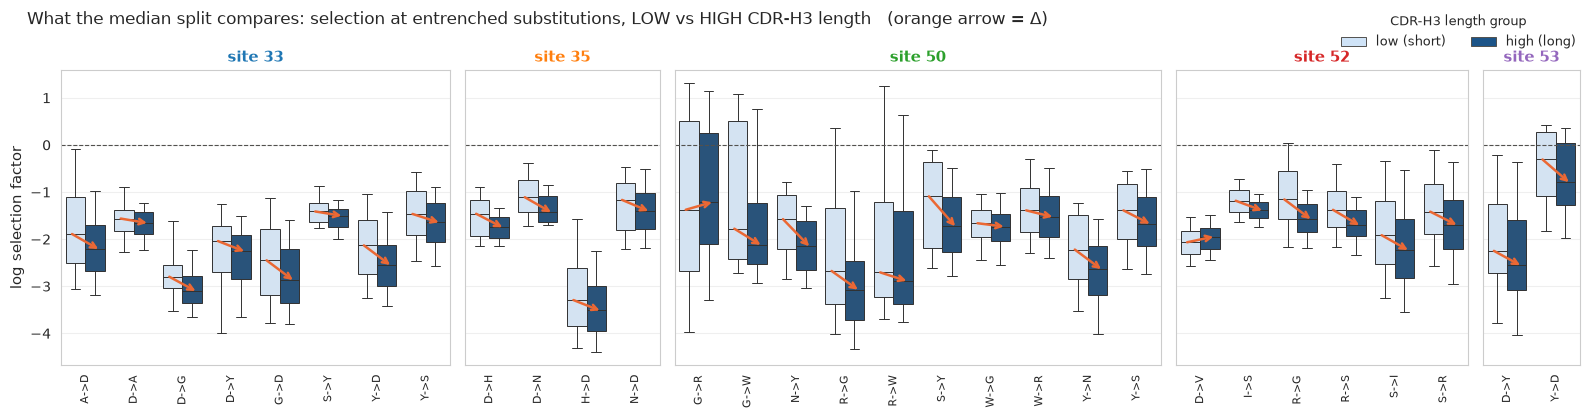

In [7]:
def entrenched_example(bins, colors, labels, title, ylab_note=""):
    '''Raw log selection factors at the entrenched substitutions, split into `bins` groups.'''
    fam = sub_df[POOL + ["family_key", "cdr3_length"]].drop_duplicates()
    if bins == 2:
        # the same single median split the statistics use
        fam["grp"], _ = hi_lo_labels(fam, "cdr3_length")
    else:
        fam["grp"] = fam.groupby(POOL, observed=True).cdr3_length.transform(
            lambda x: pd.qcut(x, bins, labels=False, duplicates="drop"))
    b = sub_df.merge(fam[POOL + ["family_key", "grp"]], on=POOL + ["family_key"],
                     how="left").dropna(subset=["grp"])
    b["substitution"] = b.parent_aa + "->" + b.selection_factor_target_aa
    # restrict to the same units the statistics use: entrenched AND passing min_families
    keep = set(zip(LEN.site, LEN.parent_aa, LEN.selection_factor_target_aa))
    ent = b[[(s, a, t) in WITHIN_PAIRS and (s, a, t) in keep for s, a, t in
             zip(b.site, b.parent_aa, b.selection_factor_target_aa)]]
    subs_by_site = {s: sorted(g.substitution.unique())
                    for s, g in ent.groupby("site", observed=True)}
    sites = [s for s in ENT_SITES if s in subs_by_site]
    fig, axes = plt.subplots(1, len(sites), figsize=(16, 4.2), sharey=True,
                             gridspec_kw={"width_ratios": [len(subs_by_site[s])
                                                           for s in sites]})
    for ax, site in zip(np.atleast_1d(axes), sites):
        subs = subs_by_site[site]
        d = ent[ent.site == site]
        sns.boxplot(data=d, x="substitution", y="log_selection_factor", hue="grp",
                    order=subs, palette=colors, showfliers=False, whis=[5, 95],
                    linewidth=0.7, ax=ax, legend=False)
        med = d.groupby(["substitution", "grp"], observed=True).log_selection_factor.median()
        for i, sub in enumerate(subs):
            lo, hi = med.get((sub, 0)), med.get((sub, bins - 1))
            if lo is not None and hi is not None:
                ax.annotate("", xy=(i + 0.27, hi), xytext=(i - 0.27, lo),
                            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.8,
                                            shrinkA=0, shrinkB=0), zorder=6)
        ax.axhline(0, color="#52514e", lw=0.8, ls="--")
        ax.set_title(f"site {site}", fontsize=11, fontweight="bold",
                     color=ENTRENCHED_SITE_COLORS.get(site, BLUE))
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel("log selection factor", fontsize=10.5)
    handles = [plt.matplotlib.patches.Patch(facecolor=c, edgecolor="#52514e", lw=0.7)
               for c in colors]
    fig.legend(handles, labels, title=f"CDR-H3 length{ylab_note}", ncol=len(labels),
               fontsize=9, title_fontsize=9, loc="upper right",
               bbox_to_anchor=(0.995, 1.0), frameon=False)
    fig.suptitle(title, fontsize=12, x=0.02, ha="left")
    plt.tight_layout()
    plt.show()


entrenched_example(2, ["#cfe3f7", "#1c5488"], ["low (short)", "high (long)"],
                   "What the median split compares: selection at entrenched substitutions, "
                   "LOW vs HIGH CDR-H3 length   (orange arrow = $\\Delta$)",
                   ylab_note=" group")

## 3. Along the V region

Plotting helpers, the site axis, and the structural burial track
(`burial = -rsa_vdj_junction_effect`, whiskers 5-95%, as in `sasa_plotting.py`). Figures are drawn
per V family in Section 3b.

In [8]:
sa = pd.read_csv(SASA_PATH, dtype={"site": str},
                 usecols=["pdb_id", "v_gene_heavy", "site", "chain_id", "heavy_chain_id",
                          "rsa_heavy_only", "rsa_vdj_junction_effect",
                          "rsa_antigen_effect", "rsa_light_effect"])
sa = sa[(sa.chain_id == sa.heavy_chain_id)
        & sa.v_gene_heavy.str.extract(r"(IGHV\d+)")[0].isin(V_FAMILIES)]
# CDR-H3 length per structure, before v_region_only (sites <= 94) removes the window
STRUCT_CDR3_LEN = cu.cdr3_length_by(sa, "pdb_id", NUMBERING).rename("cdr3_len")
sa = cu.v_region_only(sa)
sa_b = sa.dropna(subset=["rsa_vdj_junction_effect"]).copy()
sa_b["burial_by_vdj_junction"] = -sa_b.rsa_vdj_junction_effect

SITES = sort_antibody_sites(set(split.site) & set(sa_b.site))


def ent_sites_for(v_family=None):
    '''Sites with an entrenched pair in this V family (union of both if None).'''
    pairs = WITHIN_PAIRS if v_family is None else WITHIN_PAIRS_BY_FAMILY[v_family]
    return sort_antibody_sites({x for x, _, _ in pairs})


def pal_for(v_family=None):
    '''Box colours: only sites entrenched IN THIS V FAMILY are coloured.'''
    es = set(ent_sites_for(v_family))
    return [ENTRENCHED_SITE_COLORS.get(s, "#e0e0e0") if s in es else "#e0e0e0"
            for s in SITES]


VALUE_LAB = {"delta": "signed", "abs_delta": "|$\\Delta$|",
             "delta_corrected": "signed, corrected",
             "abs_delta_corrected": "|$\\Delta$| corrected"}
LAB = {"cdr3_length": "CDR-H3 length", "cdr3_charge": "CDR-H3 net charge",
       "cdr3_hydrophobicity": "CDR-H3 hydrophobicity"}


def burial_panel(ax, v_family=None):
    '''Structural burial track. v_family restricts to that family's structures.'''
    b = sa_b[sa_b.site.isin(SITES)]
    if v_family is not None:
        b = b[b.v_gene_heavy.str.extract(r"(IGHV\d+)")[0] == v_family]
    ax.set_axisbelow(True)
    sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,
                palette=pal_for(v_family), whis=[5, 95], showfliers=False, width=0.7,
                ax=ax)
    add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
    ax.set_ylim(*BURIAL_YLIM)
    ax.set_ylabel("$\\Delta$ RSA CDR3\n(burial by CDR-H3)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(len(SITES)))
    ax.set_xticklabels(SITES, rotation=90, fontsize=7)
    for lbl in ax.get_xticklabels():
        if lbl.get_text() in ent_sites_for(v_family):
            lbl.set_color(ENTRENCHED_SITE_COLORS.get(lbl.get_text(), BLUE))
            lbl.set_fontweight("bold")
    tag = f"{v_family} structures only" if v_family else "IGHV1 + IGHV3 pooled"
    ax.set_xlabel(f"site (Chothia)   —   {tag} "
                  f"(n={b.pdb_id.nunique():,})", fontsize=11)


def along_v_region(kind, title, data=None, value="delta", ylab=None,
                   v_family=None):
    '''One row of panels per CDR-H3 descriptor, plus the structural burial track.

    kind   "points" (one dot per substitution) or "box" (boxplot over substitutions)
    value  "delta" (signed) or "abs_delta" (magnitude)
    data   defaults to the pooled `split`; pass a subset for a per-V-family version
    '''
    src = split if data is None else data
    fig, axes = plt.subplots(4, 1, figsize=(17, 13.6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 3, 3, 2], "hspace": 0.20})
    rng = np.random.default_rng(1)
    for ax, desc in zip(axes[:3], cu.CDR3_DESCRIPTORS):
        s = src[(src.descriptor == desc) & src.site.isin(SITES)].copy()
        s["site"] = pd.Categorical(s.site, categories=SITES, ordered=True)
        add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
        ax.axhline(0, color="#3d3c3a", lw=1.0, zorder=3)
        if kind == "points":
            idx = {v: i for i, v in enumerate(SITES)}
            x = s.site.map(idx).to_numpy() + (rng.random(len(s)) - 0.5) * 0.55
            ax.scatter(x[~s.entrenched], s[value][~s.entrenched], s=16, c=GREY_DOT,
                       alpha=0.6, lw=0, zorder=4)
            for site in ent_sites_for(v_family):
                m = (s.entrenched & (s.site.astype(str) == site)).to_numpy()
                ax.scatter(x[m], s[value][m], s=52,
                           color=ENTRENCHED_SITE_COLORS.get(site, BLUE),
                           edgecolor="white", lw=0.7, zorder=6)
            med = s.groupby("site", observed=True)[value].median().reindex(SITES)
            for i, mm in enumerate(med):
                if np.isfinite(mm):
                    ax.plot([i - 0.36, i + 0.36], [mm, mm], color="#1a1a1a", lw=1.6,
                            zorder=7, alpha=0.8)
        else:
            # 5-95% whiskers, matching sasa_plotting.py.
            # Full-range whiskers were tried and rejected: their reach grows with the
            # number of substitutions at a site, and entrenched sites are the busiest
            # (27-63 vs a median of 12), so they would stretch exactly the sites the
            # argument rests on. Fig 2 plots every substitution, so nothing is hidden.
            sns.boxplot(data=s, x="site", y=value, order=SITES,
                        palette=pal_for(v_family), whis=[5, 95], showfliers=False,
                        width=0.7, linewidth=0.7, ax=ax, zorder=4)
            e = s[s.entrenched]      # already labelled with this family's pairs
            if len(e):
                sns.stripplot(data=e, x="site", y=value, order=SITES, hue="site",
                              palette={x: ENTRENCHED_SITE_COLORS.get(x, BLUE) for x in SITES},
                              size=5.5, jitter=0.18, edgecolor="white", linewidth=0.6,
                              legend=False, ax=ax, zorder=7)
        pre = ylab if ylab else "$\\Delta$ log selection factor"
        ax.set_ylabel(f"{pre}\nhigh $-$ low {LAB[desc]}", fontsize=10)
        ax.set_xlabel(""); ax.grid(True, axis="y", alpha=0.3)
        # full data range with a small pad: nothing is clipped
        lo, hi = float(s[value].min()), float(s[value].max())
        pad = 0.04 * (hi - lo) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)
        # title reports the column actually plotted, so the raw and variance-corrected
        # versions of this figure cannot be confused for one another
        m = s.groupby("contact_class", observed=True)[value].median()
        cc, nn = m.get("contacting", np.nan), m.get("rest", np.nan)
        ratio = (f"   |   ratio {cc / nn:.2f}x"
                 if value.startswith("abs_") and np.isfinite(nn) and nn != 0 else "")
        ax.set_title(f"{LAB[desc]}   {VALUE_LAB[value]} median: contacting {cc:+.3f}, "
                     f"rest {nn:+.3f}{ratio}",
                     loc="left", fontsize=9.5, pad=5)
    burial_panel(axes[3], v_family=v_family)
    fig.suptitle(title, fontsize=13, x=0.02, ha="left")
    plt.tight_layout()
    plt.show()

### 3a. Per V family

IGHV3 supplies ~70% of the rows, and sites 35 and 53 are entrenched only in IGHV3, so each
family is also run on its own, with its own median split and noise floor. `ent_down_raw` and
`ent_down` count raw and corrected Δ < 0 at entrenched substitutions.

In [9]:
fam_rows = []
split_by_family = {}
for vf in V_FAMILIES + ["pooled"]:
    d_vf = sub_df if vf == "pooled" else sub_df[sub_df.v_family == vf]
    # the null depends on the families and their spread, not on the descriptor, so it is
    # computed once per subset and shared across the three CDR-H3 properties
    null_vf = NULL_POOLED if vf == "pooled" else null_abs_delta(d_vf)
    per_desc = []
    pairs_vf = WITHIN_PAIRS if vf == "pooled" else WITHIN_PAIRS_BY_FAMILY[vf]
    for desc in cu.CDR3_DESCRIPTORS:
        s = binary_deltas(d_vf, desc, CONTACT[vf], pairs=pairs_vf, null=null_vf)
        per_desc.append(s)
        e = s[s.entrenched]
        c, n = s[s.contact_class == "contacting"], s[s.contact_class == "rest"]
        fam_rows.append({
            "v_family": vf, "descriptor": desc, "n_units": len(s), "n_ent": len(e),
            # corrected values, i.e. what panels A and B of the Section 7 figure
            # plot; substitutions that do not clear their own floor sit at zero and
            # count as neither direction
            "ent_down_raw": int((e.delta < 0).sum()) if len(e) else np.nan,
            "ent_down": int((e.delta_corrected < 0).sum()) if len(e) else np.nan,
            "ent_at_zero": int((e.delta_corrected == 0).sum()) if len(e) else np.nan,
            "ent_pct_down": 100 * (e.delta_corrected < 0).mean() if len(e) else np.nan,
            "ent_median": e.delta_corrected.median() if len(e) else np.nan,
            "contacting_median": c.delta.median(), "rest_median": n.delta.median(),
            "abs_contacting": c.abs_delta_corrected.median(),
            "abs_rest": n.abs_delta_corrected.median(),
            "abs_ratio": c.abs_delta_corrected.median() / n.abs_delta_corrected.median(),
            "rho_abs_contact": spearmanr(s.contact, s.abs_delta_corrected)[0],
            "p_abs_contact": spearmanr(s.contact, s.abs_delta_corrected)[1]})
    split_by_family[vf] = pd.concat(per_desc, ignore_index=True)
by_family = pd.DataFrame(fam_rows)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(by_family[by_family.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))

  cdr3_length: split at 13 (46% of family-pool entries in the high half)


  cdr3_charge: split at -1.25538 (49% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.538462 (50% of family-pool entries in the high half)


  cdr3_length: split at 12 (43% of family-pool entries in the high half)


  cdr3_charge: split at -1.24166 (50% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.607692 (50% of family-pool entries in the high half)


  cdr3_length: split at 12 (47% of family-pool entries in the high half)


  cdr3_charge: split at -1.24177 (49% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.58 (50% of family-pool entries in the high half)



=== cdr3_length ===
v_family  n_units  n_ent  ent_down_raw  ent_down  ent_at_zero  ent_pct_down  ent_median  contacting_median  rest_median  abs_contacting  abs_rest  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1      940     15            13        10            4       66.6667     -0.0326            -0.0861      -0.0170          0.0788    0.0325     2.4235           0.0449         0.1692
   IGHV3     1100     18            17        16            1       88.8889     -0.2701            -0.1972       0.0200          0.1580    0.0799     1.9782           0.2152         0.0000
  pooled     1561     30            28        26            2       86.6667     -0.2296            -0.1834       0.0058          0.1285    0.0605     2.1246           0.1434         0.0000

=== cdr3_charge ===
v_family  n_units  n_ent  ent_down_raw  ent_down  ent_at_zero  ent_pct_down  ent_median  contacting_median  rest_median  abs_contacting  abs_rest  abs_ratio  rho_abs_contact  p_abs_contact
   IGHV1     

### 3b. Along the V region, per V family

For each family: raw Δ, corrected Δ, and corrected |Δ|. A substitution that does not clear
its floor sits at zero, which means it cannot be told apart from its floor, not that its
effect is zero.

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


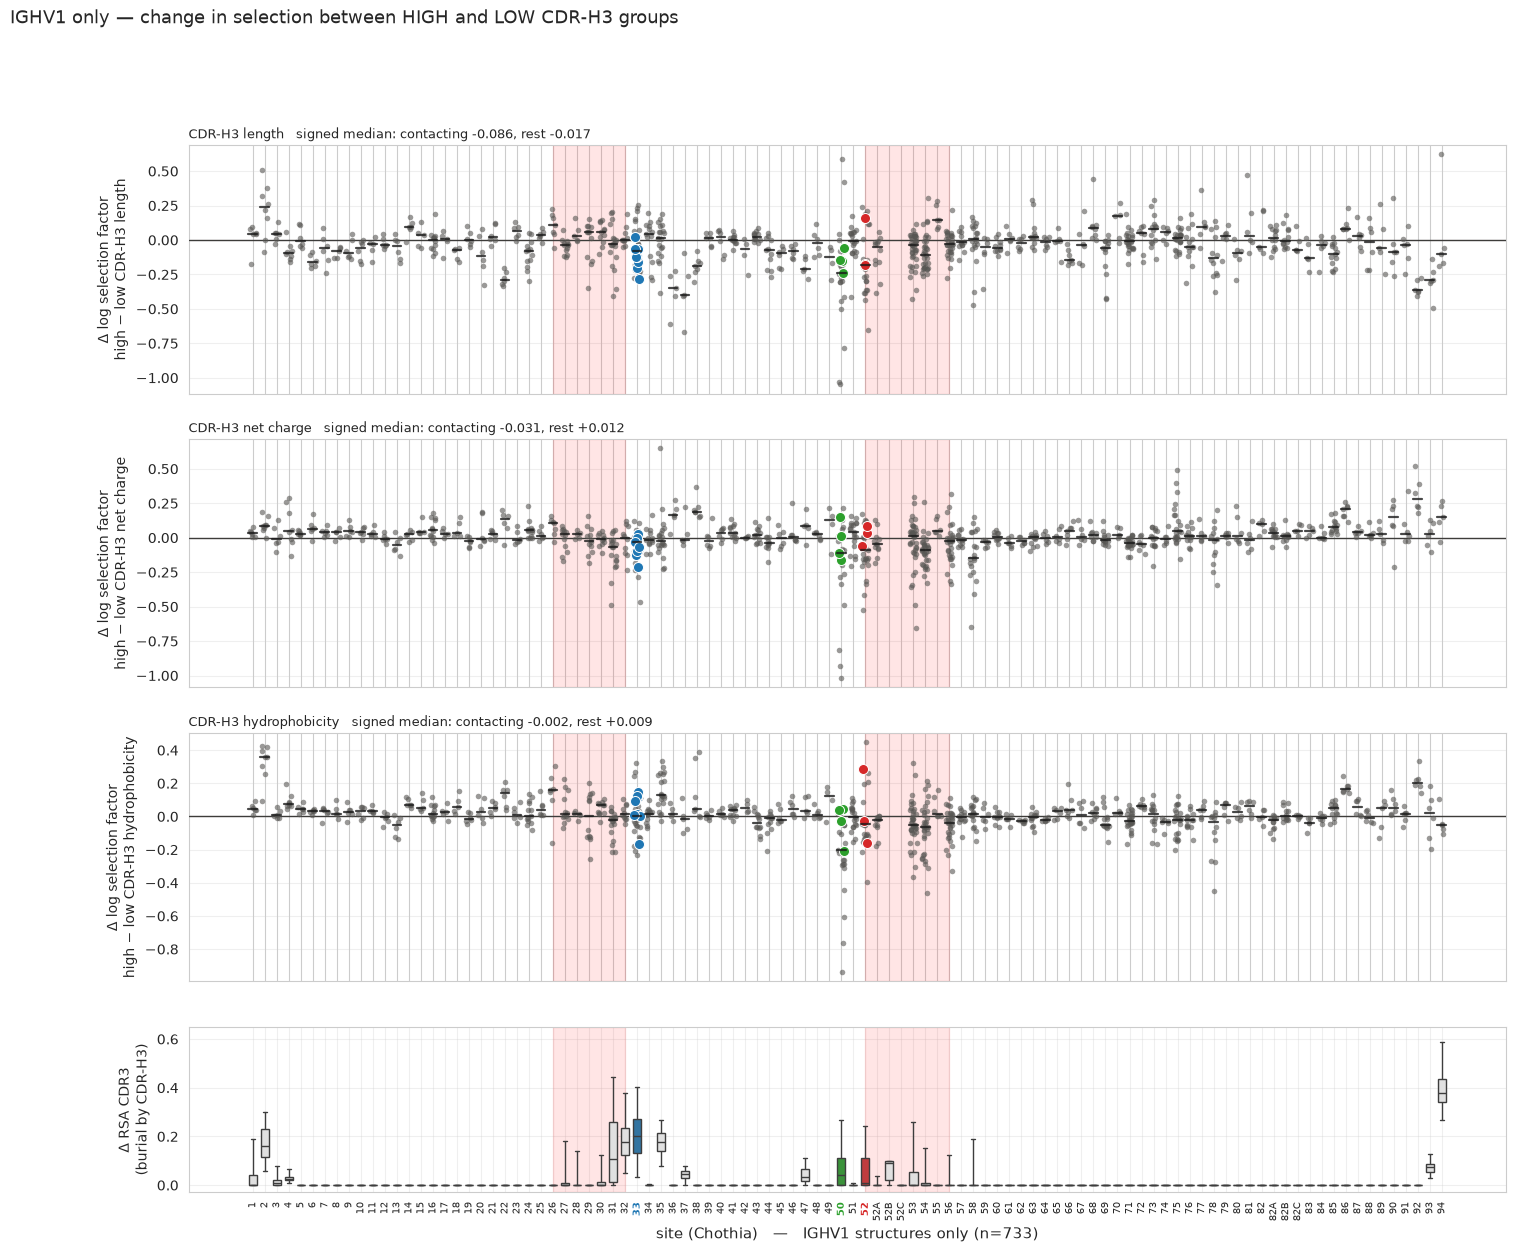

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


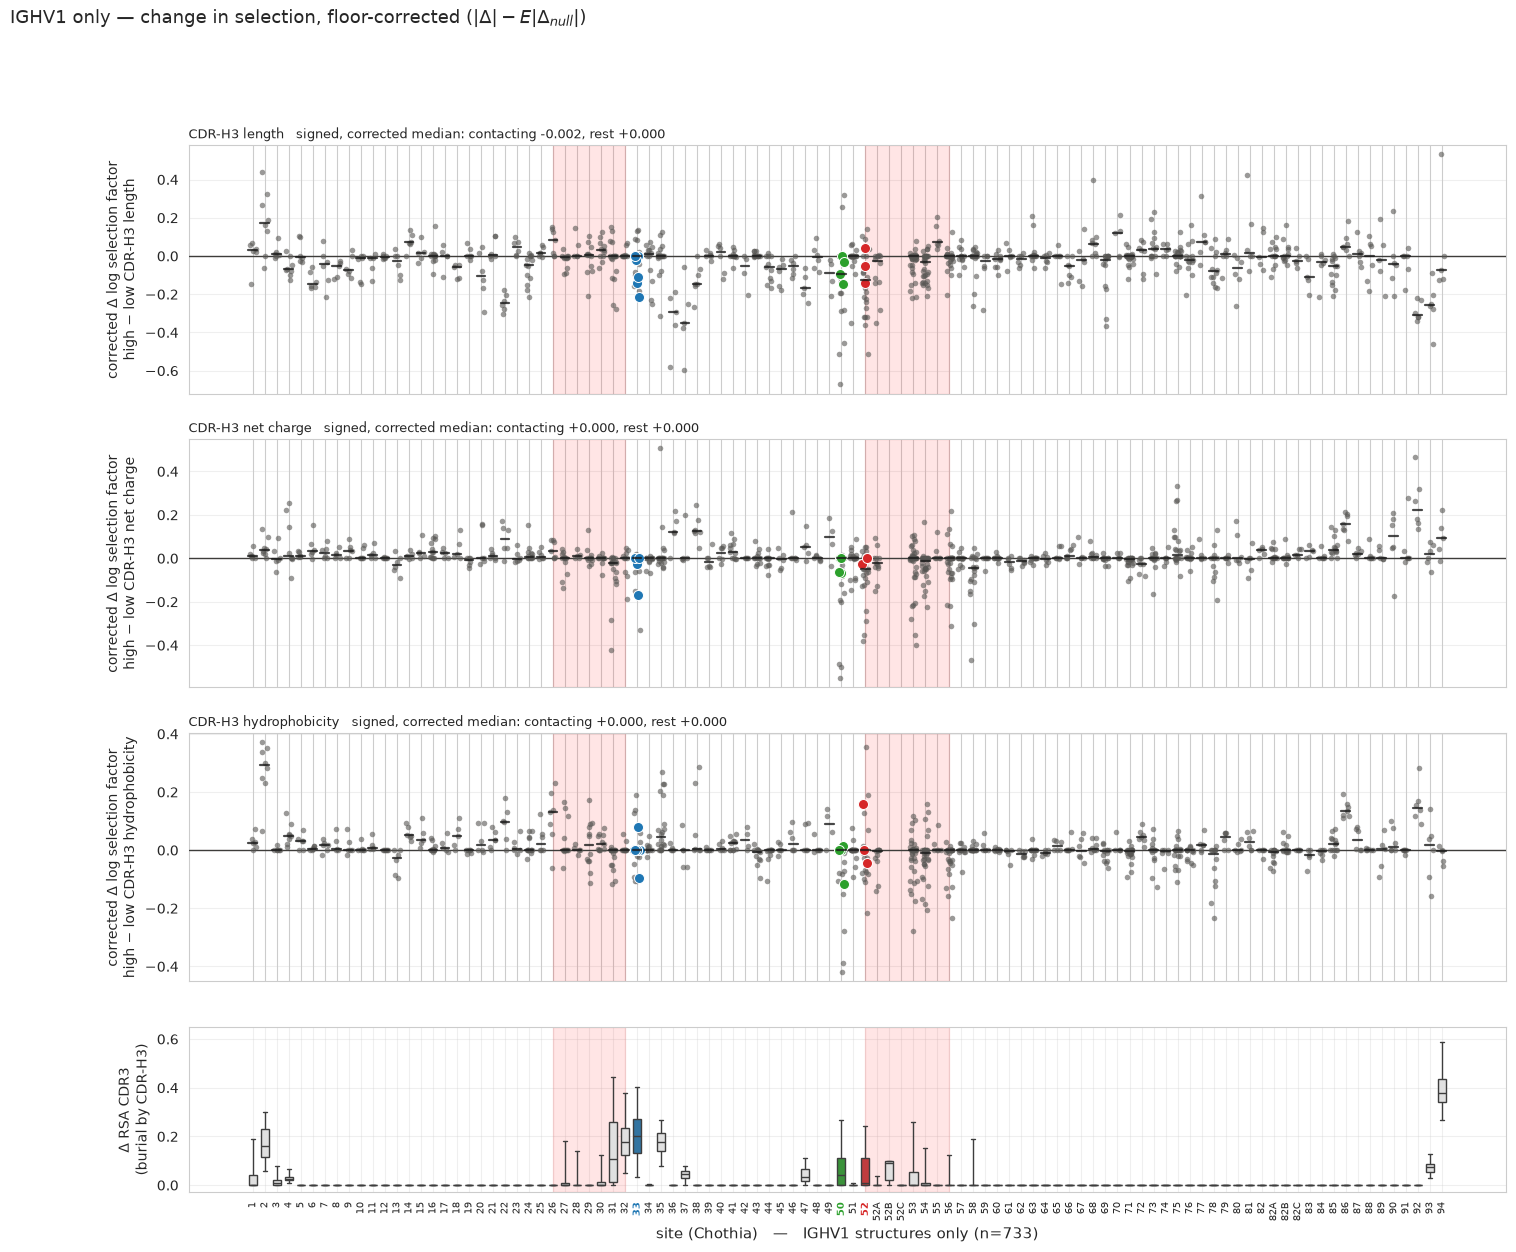

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


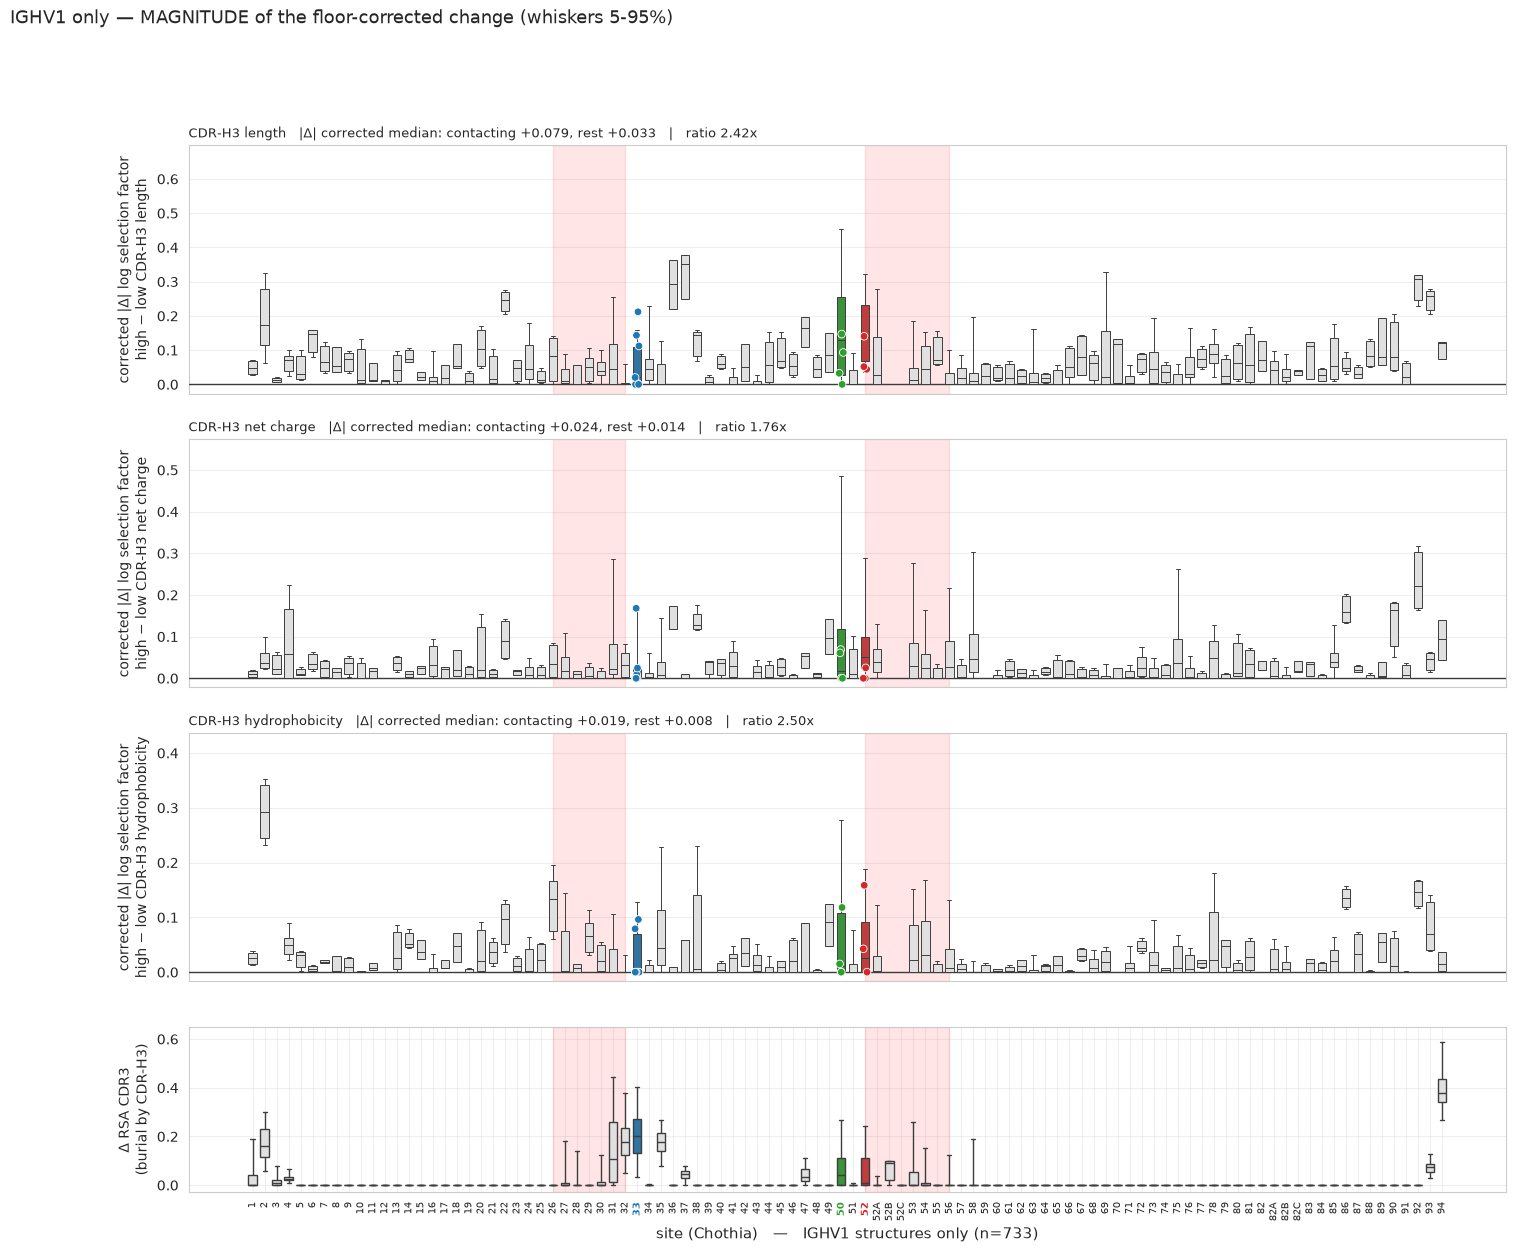

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


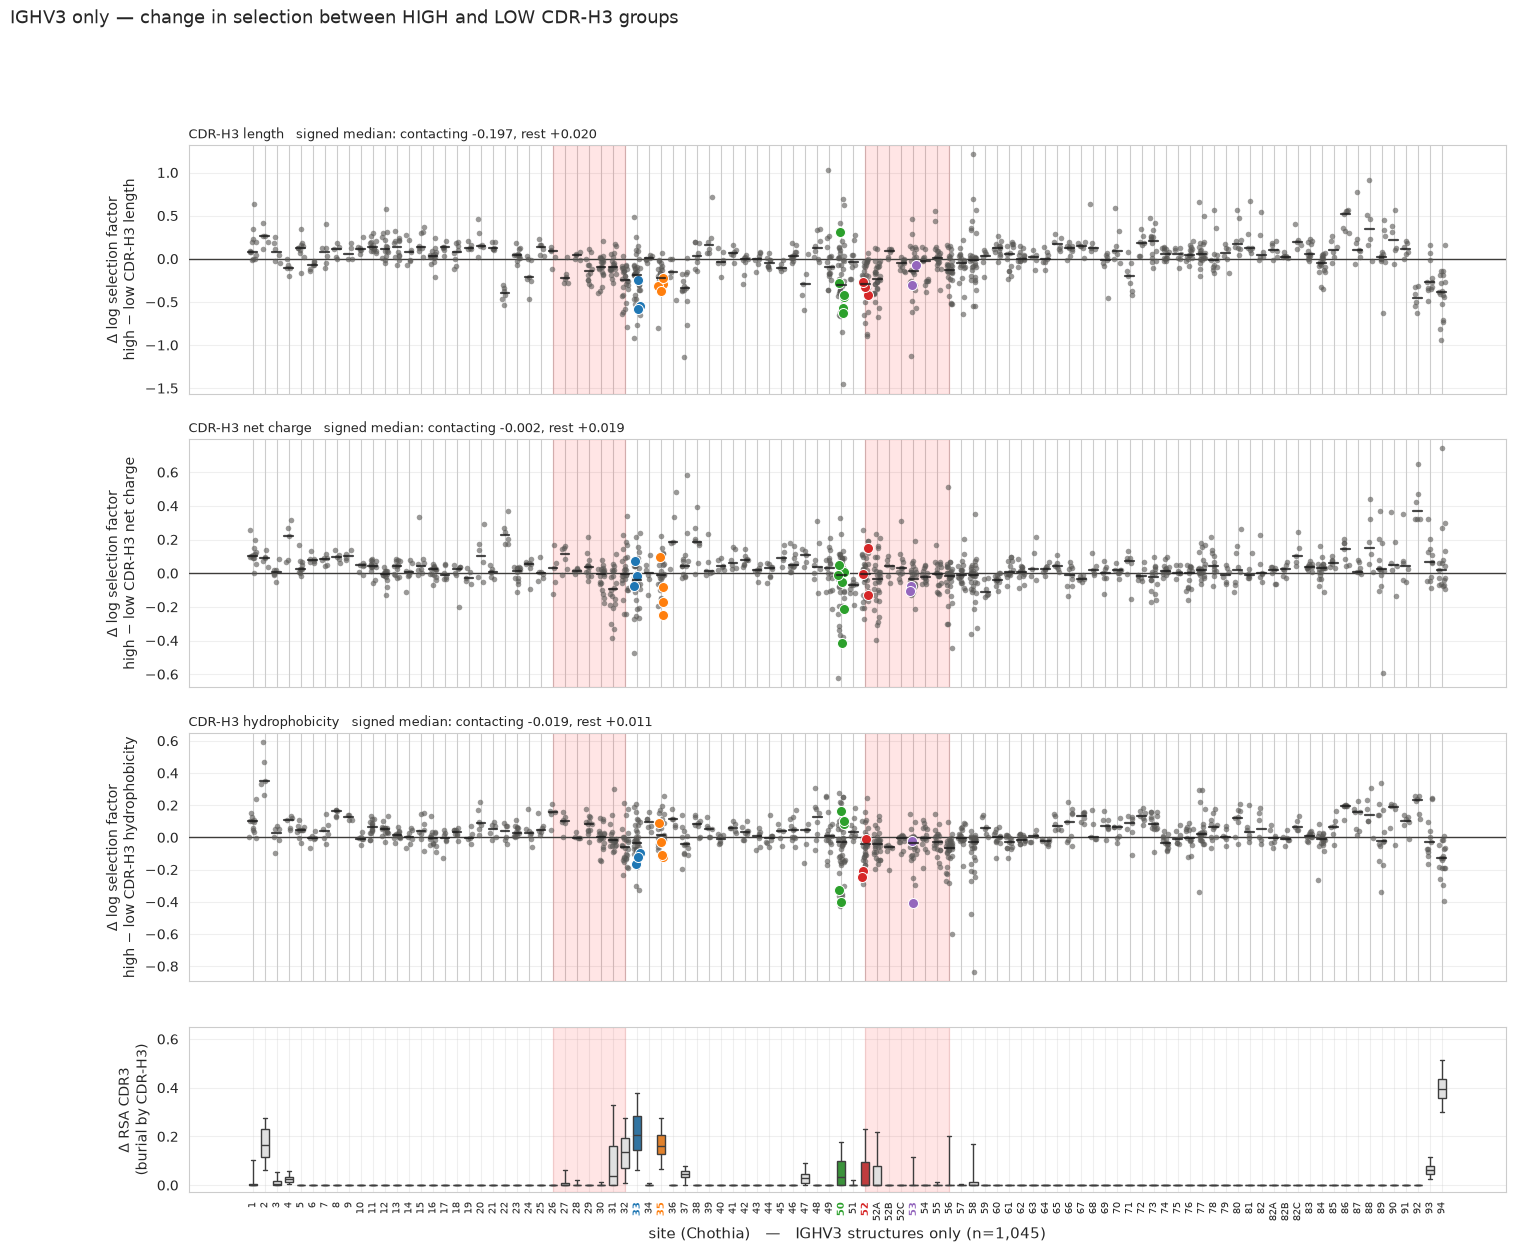

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


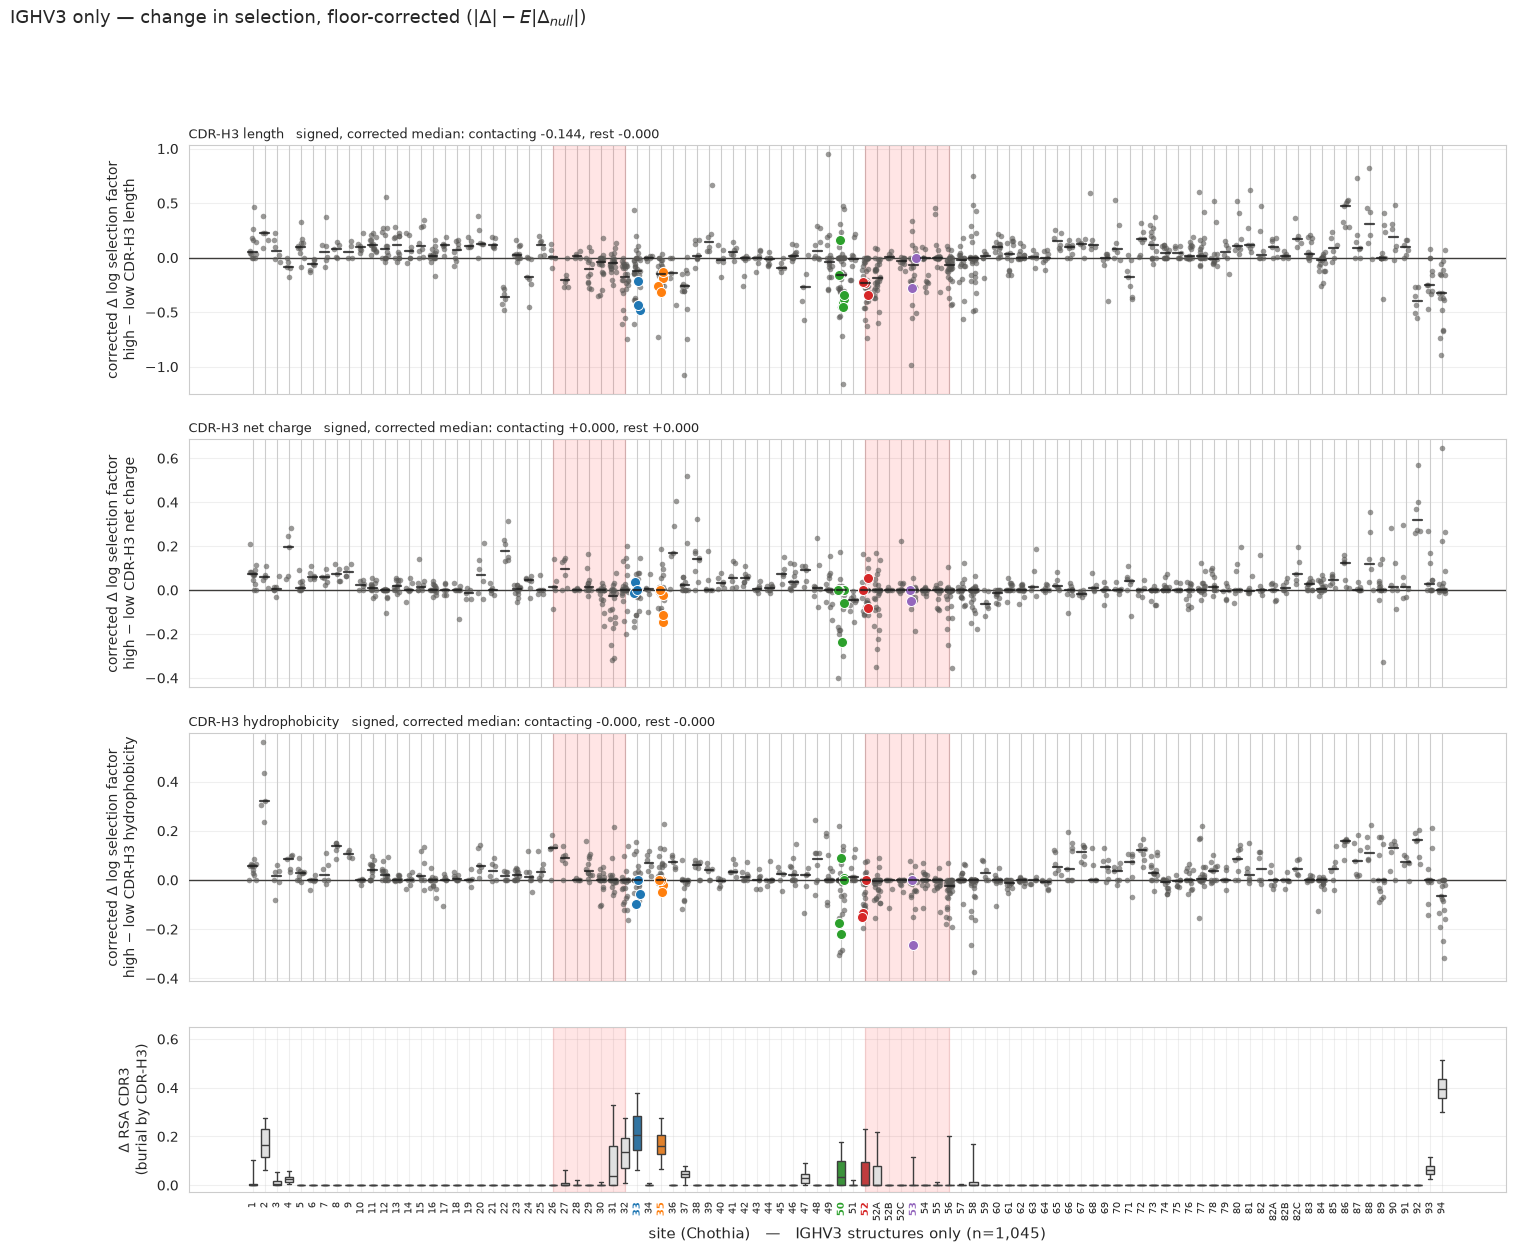

/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="site", y=value, order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=b, x="site", y="burial_by_vdj_junction", order=SITES,


/loc/scratch/nharel/claude-83096/-home-nharel-re/f1f8ee69-6081-4ac2-ae40-f017d9e8915d/scratchpad/ipykernel_4020646/198023434.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


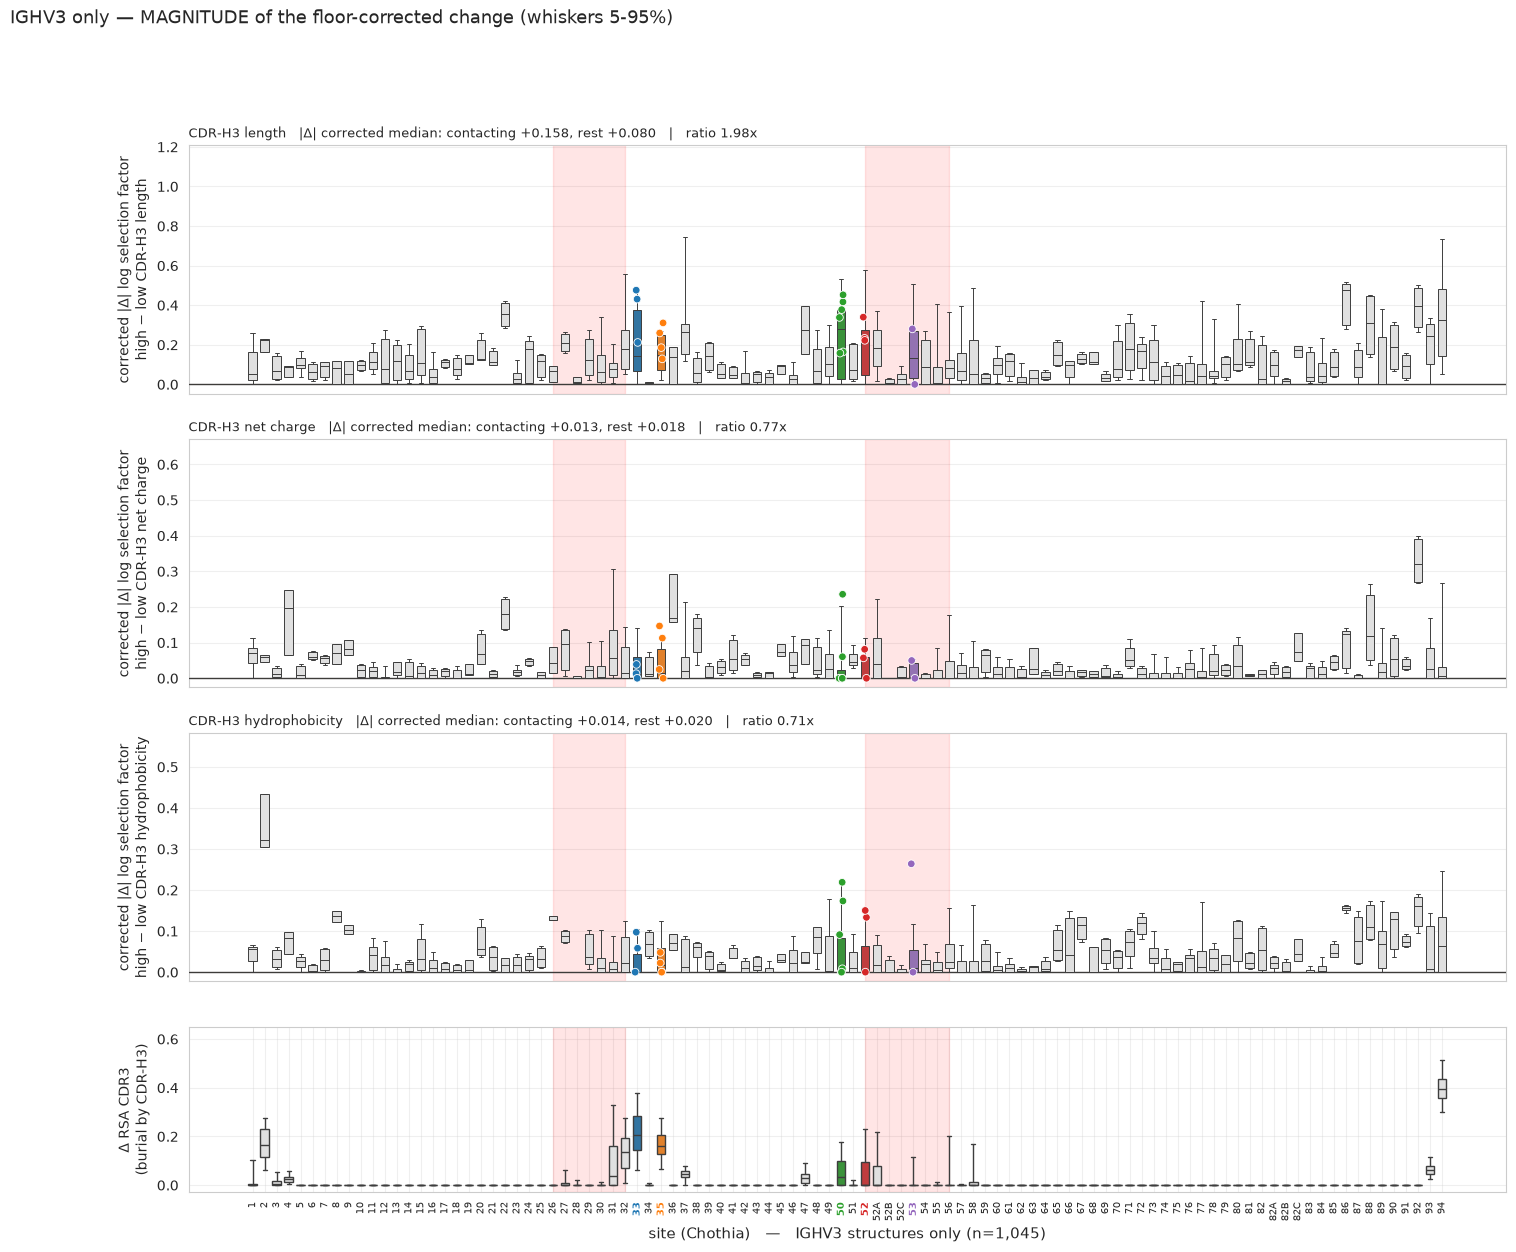

In [10]:
for vf in V_FAMILIES:
    along_v_region("points",
                   f"{vf} only — change in selection between HIGH and LOW CDR-H3 groups",
                   data=split_by_family[vf], v_family=vf)
    # same points after subtracting each substitution's own noise floor: anything that
    # does not clear its floor sits exactly on zero, so the panel is self-calibrating and
    # needs no band
    along_v_region("points",
                   f"{vf} only — change in selection, floor-corrected "
                   f"($|\\Delta| - E|\\Delta_{{null}}|$)",
                   data=split_by_family[vf], value="delta_corrected",
                   ylab="corrected $\\Delta$ log selection factor", v_family=vf)
    along_v_region("box",
                   f"{vf} only — MAGNITUDE of the floor-corrected change "
                   f"(whiskers 5-95%)",
                   data=split_by_family[vf], value="abs_delta_corrected",
                   ylab="corrected |$\\Delta$| log selection factor", v_family=vf)

## 4. Nuisance variables, and whether entrenchment adds anything

Per-site rank regressions of the signed shift (CDR-H3 length). Entrenched sites have the
most substitutions (germline diversity creates units), so `n_subs` is included. The
second cell checks that the per-site germline-codon filter does not select families by
CDR-H3 length.

In [11]:
per_site = LEN.groupby("site").agg(
    shift=("delta", "median"), abs_shift=("abs_delta_corrected", "median"), n_subs=("delta", "size"),
    n_fam=("n_families", "median"), iqr=("iqr", "median")).join(
    classified[["cdr3_contact_freq"]]).dropna()
per_site = per_site[per_site.n_subs >= 5]
per_site["ent"] = per_site.index.isin(ENT_SITES).astype(float)
print(f"{len(per_site)} sites.  entrenched n_subs: "
      + ", ".join(f"{i}={int(r.n_subs)}" for i, r in per_site[per_site.ent == 1].iterrows())
      + f"   |  median elsewhere = {per_site[per_site.ent==0].n_subs.median():.0f}")
print("\nmarginal Spearman vs per-site shift:")
for c in ["cdr3_contact_freq", "n_subs", "n_fam", "iqr"]:
    rr, pp = spearmanr(per_site[c], per_site["shift"])
    print(f"  {c:20s} rho={rr:+.3f}  p={pp:.2e}")


def rank_ols(y, cols, label):
    X = pd.DataFrame({c: (per_site[c].rank() if c != "ent" else per_site[c]) for c in cols})
    X = (X - X.mean()) / X.std(ddof=0); X.insert(0, "const", 1.0)
    m = OLS(np.asarray(per_site[y].rank(), float), np.asarray(X, float)).fit()
    terms = "   ".join(f"{n}: b={b:+.2f} p={p:.1e}"
                       for n, b, p in zip(X.columns, m.params, m.pvalues) if n != "const")
    print(f"  {label:34s} R2={m.rsquared:.3f}   {terms}")


print("\nrank regressions on the per-site signed shift:")
rank_ols("shift", ["ent"], "~ entrenched")
rank_ols("shift", ["ent", "cdr3_contact_freq"], "~ entrenched + contact")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs"], "~ entrenched + contact + n_subs")
rank_ols("shift", ["ent", "cdr3_contact_freq", "n_subs", "n_fam"], "~ + n_fam")

100 sites.  entrenched n_subs: 33=46, 35=27, 50=66, 52=53, 53=45   |  median elsewhere = 12

marginal Spearman vs per-site shift:
  cdr3_contact_freq    rho=-0.555  p=2.09e-09
  n_subs               rho=-0.428  p=9.10e-06
  n_fam                rho=+0.401  p=3.52e-05
  iqr                  rho=+0.055  p=5.85e-01

rank regressions on the per-site signed shift:
  ~ entrenched                       R2=0.104   ent: b=-9.29 p=1.1e-03
  ~ entrenched + contact             R2=0.327   ent: b=-4.26 p=1.0e-01   cdr3_contact_freq: b=-14.54 p=1.4e-07
  ~ entrenched + contact + n_subs    R2=0.400   ent: b=-1.55 p=5.4e-01   cdr3_contact_freq: b=-13.39 p=3.8e-07   n_subs: b=-8.48 p=9.1e-04
  ~ + n_fam                          R2=0.400   ent: b=-1.55 p=5.5e-01   cdr3_contact_freq: b=-13.40 p=7.2e-07   n_subs: b=-8.53 p=4.9e-02   n_fam: b=-0.07 p=9.9e-01


In [12]:
# The germline-codon filter is applied per site, so it could in principle select families
# non-randomly by CDR-H3 length. It does not: the shift is uniform across the V region
# and unrelated to the per-site result.
gl = aa_v.drop_duplicates(["pcp_index", "site"])[["pcp_index", "site", "is_germline_codon"]]
gl = gl.merge(pcp_df[["pcp_index", "family_key", "cdr3_length"]], on="pcp_index")
gl = gl.drop_duplicates(["family_key", "site"]).dropna(subset=["cdr3_length"])
gl["tert"] = pd.qcut(gl.cdr3_length, 3, labels=["short", "mid", "long"])
ret = gl.pivot_table(index="site", columns="tert", values="is_germline_codon",
                     aggfunc="mean", observed=True)
ret["delta_ret"] = ret["long"] - ret["short"]
ret = ret.join(classified[["cdr3_contact_freq"]]).dropna()
print("germline-state retention (parent still carries the germline codon):")
print(f"  overall  short {gl[gl.tert=='short'].is_germline_codon.mean():.3f}   "
      f"mid {gl[gl.tert=='mid'].is_germline_codon.mean():.3f}   "
      f"long {gl[gl.tert=='long'].is_germline_codon.mean():.3f}")
rr, pp = spearmanr(ret.cdr3_contact_freq, ret.delta_ret)
print(f"  retention change vs contact frequency: rho={rr:+.3f} p={pp:.2f}")
j = ret.join(per_site[["shift"]]).dropna()
rr, pp = spearmanr(j.delta_ret, j["shift"])
print(f"  retention change vs per-site shift:    rho={rr:+.3f} p={pp:.2f}")
print("-> the per-site germline filter does not drive the contact result.")

germline-state retention (parent still carries the germline codon):
  overall  short 0.880   mid 0.859   long 0.853
  retention change vs contact frequency: rho=-0.096 p=0.34
  retention change vs per-site shift:    rho=+0.121 p=0.23
-> the per-site germline filter does not drive the contact result.


### 4a. Germline diversity

Contacting sites are also the germline-diverse ones. Unit: (site, V family). Diversity is the
number (and entropy) of germline residues within the V family, counted over every family's
germline assignment rather than only the residues that clear `MIN_FAMILIES`. Monomorphic
units are kept as a k=1 bin. Diversity could only confound the result if it were both higher at
contacting units and positively related to the corrected magnitude.

195 (site, V family) units over 100 sites: 25 contacting, 170 rest
v_family  c    
IGHV1     False    83
          True     13
IGHV3     False    87
          True     12

units per germline-diversity bin (contacting / rest):
c   rest  contacting
kb                  
1     88           8
2     48           2
3     17           4
4      6           4
≥5    11           7


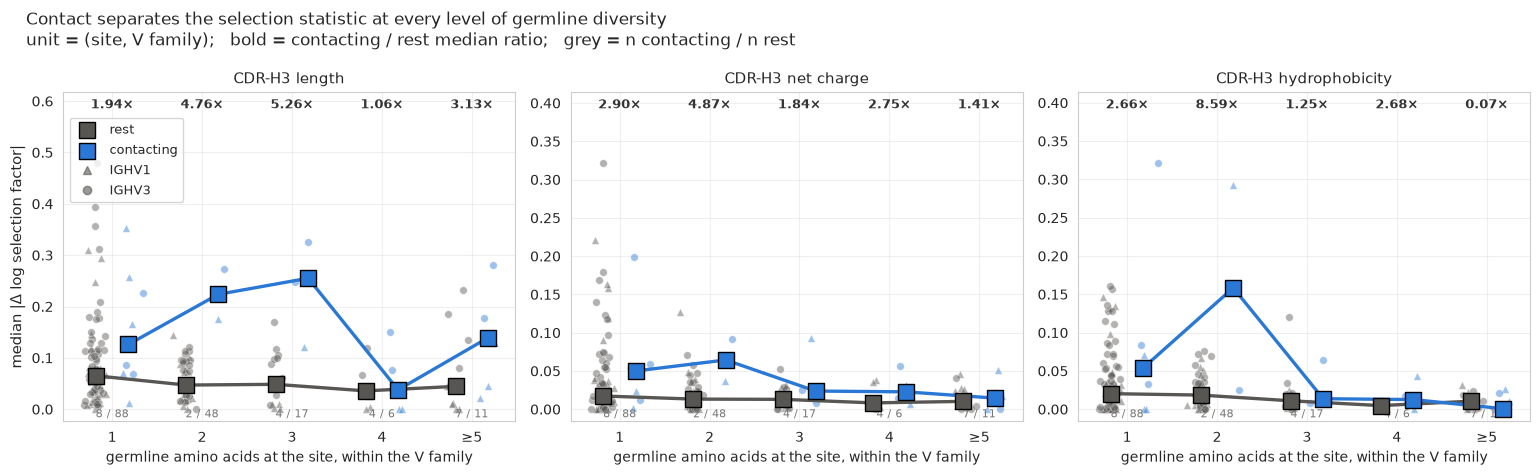


contacting / rest median ratio within each diversity bin:
bin                             0     1     2     3     4    Q1    Q2    Q3    Q4    ≥5
descriptor          binning                                                            
cdr3_charge         entropy  2.90   NaN   NaN   NaN   NaN  3.17  1.86  4.31  1.43   NaN
                    k         NaN  2.90  4.87  1.84  2.75   NaN   NaN   NaN   NaN  1.41
cdr3_hydrophobicity entropy  2.66   NaN   NaN   NaN   NaN  8.13  0.57  2.46  1.40   NaN
                    k         NaN  2.66  8.59  1.25  2.68   NaN   NaN   NaN   NaN  0.07
cdr3_length         entropy  1.94   NaN   NaN   NaN   NaN  3.04  4.41  3.13  3.13   NaN
                    k         NaN  1.94  4.76  5.26  1.06   NaN   NaN   NaN   NaN  3.13

contact ratio above 1 in 28 of 30 comparable (descriptor x binning x bin) cells; 0 bins have no contacting unit
  k        contacting 3.00 vs rest 1.00  (p=0.0010)
  entropy  contacting 0.42 vs rest 0.00  (p=0.0069)
  CDR-H3 length     

In [13]:
# Germline diversity per (V family, site), from the germline assignment of every clonal
# family in the analysis. Two changes from the pooled version this replaces. First, the
# unit is (site, V family), as in the site-level test of Section 2a: IGHV1 and IGHV3 are
# independent replicates, so pooling them here threw away half the comparison. Second,
# diversity is counted WITHIN a V family -- pooled over both it counts residues that
# differ between IGHV1 and IGHV3 rather than polymorphism a family can be stratified on
# (site 37 is monomorphic in IGHV1 and k=4 in IGHV3, so pooling calls it k=4).
# Deliberately independent of the analysis filters: counting only residues that clear
# MIN_FAMILIES would bake the unit threshold into the covariate and make it close to
# n_subs, which the previous section already controls.
_germ = pd.read_csv(f"germline/germline_codons_{NUMBERING}.csv", dtype={"site": str})
_fam_v = sub_df.drop_duplicates("family_key")[["family_key", "v_family", "v_gene"]]
_per_family = _germ[_germ.site.isin(set(split.site))].merge(
    _fam_v, on="v_gene", suffixes=("_germ", ""))


diversity = pd.concat(
    {vf: calculate_shannon_entropy_per_site(g).set_index("site")
     for vf, g in _per_family.groupby("v_family")}, names=["v_family"]
).rename(columns={"n_unique_aa": "k", "shannon_entropy": "entropy"})[["k", "entropy"]]

# Monomorphic sites are kept, in a k=1 bin of their own. They carry no diversity to
# stratify on, but that is a statement about the x axis, not a reason to drop the y
# value: the question is whether contact separates the magnitude, and at k=1 it can
# still be asked because 8 of the 96 monomorphic units are CDR-H3-contacting. Dropping
# them also removed sites 3, 4 and (in IGHV1) 37, 47 and 93 -- contacted sites, so the
# exclusion was not neutral with respect to the comparison being made.
MIN_SUBS = 5
K_ORDER = ["1", "2", "3", "4", "≥5"]
MARK = {"IGHV1": "^", "IGHV3": "o"}
_units = pd.concat([split_by_family[vf].assign(v_family=vf) for vf in V_FAMILIES],
                   ignore_index=True)


def unit_frame(desc):
    '''One row per (site, V family): median corrected magnitude and its covariates.'''
    g = (_units[_units.descriptor == desc]
         .groupby(["v_family", "site"])
         .agg(y=("abs_delta_corrected", "median"), n_subs=("delta", "size"),
              contact=("contact", "first"))
         .join(diversity))
    g = g[(g.n_subs >= MIN_SUBS) & g.k.notna()].copy()
    g["c"] = g.contact > cu.CDR3_CONTACT_THRESHOLD
    g["kb"] = pd.cut(g.k, [0, 1, 2, 3, 4, np.inf], labels=K_ORDER)
    # monomorphic units have entropy exactly 0, so they form their own level rather than
    # a degenerate first quartile; the quartiles are taken over the polymorphic units
    g["ebin"] = pd.qcut(g.entropy.where(g.k > 1), 4, labels=["Q1", "Q2", "Q3", "Q4"])
    g["ebin"] = g.ebin.cat.add_categories(["0"]).fillna("0")
    return g


G = unit_frame("cdr3_length")
print(f"{len(G)} (site, V family) units over {G.index.get_level_values('site').nunique()}"
      f" sites: {int(G.c.sum())} contacting, {int((~G.c).sum())} rest")
print(G.reset_index().groupby(["v_family", "c"]).size().rename("units").to_string())
print("\nunits per germline-diversity bin (contacting / rest):")
print(pd.crosstab(G.kb, G.c).rename(columns={False: "rest", True: "contacting"})
      .to_string())

fig, axes = plt.subplots(1, len(cu.CDR3_DESCRIPTORS), figsize=(15.5, 4.8))
ratio_rows = []
for ax, desc in zip(axes, cu.CDR3_DESCRIPTORS):
    g = unit_frame(desc)
    rng = np.random.default_rng(1)
    for lab, mask, colour in [("rest", ~g.c, GREY_DOT),
                              ("contacting", g.c, BLUE)]:
        off, sub = (0.18 if lab == "contacting" else -0.18), g[mask]
        for vf, mk in MARK.items():
            s = sub[sub.index.get_level_values("v_family") == vf]
            xs = np.array([K_ORDER.index(str(b)) for b in s.kb]) + off
            ax.scatter(xs + rng.normal(0, 0.055, len(xs)), s.y, s=30, c=colour,
                       marker=mk, alpha=0.45, edgecolor="white", lw=0.5, zorder=2)
        med = sub.groupby("kb", observed=False).y.median().reindex(K_ORDER)
        xm = [K_ORDER.index(b) + off for b in K_ORDER]
        ax.plot(xm, med.values, "-", color=colour, lw=2.4, zorder=3)
        ax.scatter(xm, med.values, s=130, c=colour, marker="s", edgecolor="black",
                   lw=1.0, zorder=4, label=lab)

    for bincol, binname, order in [("kb", "k", K_ORDER),
                                   ("ebin", "entropy", ["0", "Q1", "Q2", "Q3", "Q4"])]:
        t = g.pivot_table(index=bincol, columns="c", values="y", aggfunc="median",
                          observed=False)
        n = g.groupby(bincol, observed=False).c.agg(["sum", "size"]).reindex(order)
        for b in order:
            # a bin with no contacting unit has no ratio; the counts still report it
            ratio_rows.append({
                "descriptor": desc, "binning": binname, "bin": b,
                "ratio": (t.loc[b, True] / t.loc[b, False]
                          if {True, False} <= set(t.columns) else np.nan),
                "n_contacting": int(n.loc[b, "sum"]),
                "n_rest": int(n.loc[b, "size"] - n.loc[b, "sum"])})

    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.22 * (hi - lo))
    kt = g.pivot_table(index="kb", columns="c", values="y", aggfunc="median",
                       observed=False)
    kn = g.groupby("kb", observed=False).c.agg(["sum", "size"]).reindex(K_ORDER)
    for i, b in enumerate(K_ORDER):
        r = (kt.loc[b, True] / kt.loc[b, False]
             if {True, False} <= set(kt.columns) else np.nan)
        ax.annotate(f"{r:.2f}×" if np.isfinite(r) else "—",
                    (i, ax.get_ylim()[1]), xytext=(0, -12), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", color="#333")
        ax.annotate(f"{int(kn.loc[b, 'sum'])} / {int(kn.loc[b, 'size'] - kn.loc[b, 'sum'])}",
                    (i, lo), xytext=(0, 3), textcoords="offset points", ha="center",
                    fontsize=8, color="#777")
    ax.set_xticks(range(len(K_ORDER)))
    ax.set_xticklabels(K_ORDER)
    ax.set_xlabel("germline amino acids at the site, within the V family", fontsize=10)
    ax.set_title(LAB[desc], fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("median |$\\Delta$ log selection factor|", fontsize=10.5)
_h, _l = axes[0].get_legend_handles_labels()
_h += [plt.Line2D([], [], ls="", marker=MARK[v], color=GREY_DOT, alpha=0.6) for v in MARK]
axes[0].legend(_h, _l + list(MARK), fontsize=9, loc="upper left",
               bbox_to_anchor=(0.0, 0.94))
fig.suptitle("Contact separates the selection statistic at every level of germline "
             "diversity\nunit = (site, V family);   bold = contacting / rest "
             "median ratio;   grey = n contacting / n rest", fontsize=12.5, x=0.02,
             ha="left")
plt.tight_layout()
plt.show()

by_div = pd.DataFrame(ratio_rows)
print("\ncontacting / rest median ratio within each diversity bin:")
print(by_div.pivot_table(index=["descriptor", "binning"], columns="bin", values="ratio")
      .round(2).to_string())
_ok = by_div.ratio.notna()
print(f"\ncontact ratio above 1 in {(by_div.ratio > 1).sum()} of {int(_ok.sum())} "
      f"comparable (descriptor x binning x bin) cells; "
      f"{int((~_ok).sum())} bins have no contacting unit")

# Could germline diversity confound the contrast? It would have to be higher at contacting
# units AND positively related to the corrected magnitude. The first leg holds, the second
# fails, so diversity works against the contrast rather than creating it.
_D = unit_frame("cdr3_length")
for _col in ["k", "entropy"]:
    _p = mannwhitneyu(_D.loc[_D.c, _col], _D.loc[~_D.c, _col]).pvalue
    print(f"  {_col:8s} contacting {_D.loc[_D.c, _col].median():.2f} vs rest "
          f"{_D.loc[~_D.c, _col].median():.2f}  (p={_p:.4f})")
for _desc in cu.CDR3_DESCRIPTORS:
    _d = unit_frame(_desc)
    print(f"  {LAB[_desc]:24s} rho(k, |delta|) = {spearmanr(_d.k, _d.y)[0]:+.3f}   "
          f"rho(entropy, |delta|) = {spearmanr(_d.entropy, _d.y)[0]:+.3f}")

## 5. Model-free: does a longer CDR-H3 bury these sites more?

SAbDab structures only, no DASM: Spearman correlation between each structure's CDR-H3 length
(residues at 95-102) and burial at each V-region site.

In [14]:
cdr3_len = STRUCT_CDR3_LEN
assert len(cdr3_len) > 0, "no structures with residues in the CDR-H3 window"
print(f"{len(cdr3_len):,} structures; CDR-H3 length median {cdr3_len.median():.0f}, "
      f"range {cdr3_len.min()}-{cdr3_len.max()}")
sv = sa_b.join(cdr3_len, on="pdb_id").dropna(subset=["cdr3_len"])

rows = []
for site, g in sv.groupby("site"):
    if g.pdb_id.nunique() < cu.MIN_STRUCTURES or g.burial_by_vdj_junction.nunique() < 2:
        continue                      # constant burial -> correlation undefined
    rho, pv = spearmanr(g.cdr3_len, g.burial_by_vdj_junction)
    lo = g[g.cdr3_len <= g.cdr3_len.quantile(1/3)]
    hi = g[g.cdr3_len >= g.cdr3_len.quantile(2/3)]
    rows.append({"site": site, "n_struct": g.pdb_id.nunique(), "rho": rho, "p": pv,
                 "burial_short": lo.burial_by_vdj_junction.mean(),
                 "burial_long": hi.burial_by_vdj_junction.mean(),
                 "d_burial": hi.burial_by_vdj_junction.mean()
                             - lo.burial_by_vdj_junction.mean()})
struct = pd.DataFrame(rows).set_index("site")
struct["entrenched"] = struct.index.isin(ENT_SITES)
print("\nentrenched sites:")
print(struct[struct.entrenched][["n_struct", "rho", "p", "burial_short", "burial_long",
                                 "d_burial"]].round(4).to_string())
print(f"\n{len(struct)} sites with defined rho: median {struct.rho.median():+.3f}; "
      f"entrenched {struct[struct.entrenched].rho.median():+.3f} vs others "
      f"{struct[~struct.entrenched].rho.median():+.3f}  (MW p="
      f"{mannwhitneyu(struct[struct.entrenched].rho, struct[~struct.entrenched].rho, alternative='greater').pvalue:.4f})")
print("\ntop 10 sites by rho:")
print(struct.nlargest(10, "rho")[["n_struct", "rho", "d_burial", "entrenched"]]
      .round(4).to_string())

1,778 structures; CDR-H3 length median 13, range 2-31

entrenched sites:
      n_struct     rho    p  burial_short  burial_long  d_burial
site                                                            
33        1775  0.3712  0.0        0.1718       0.2462    0.0744
35        1778  0.2208  0.0        0.1570       0.1821    0.0251
50        1778  0.2108  0.0        0.0481       0.0836    0.0355
52        1771  0.4142  0.0        0.0289       0.0921    0.0631
53        1776  0.4556  0.0        0.0045       0.0628    0.0583

52 sites with defined rho: median +0.068; entrenched +0.371 vs others +0.045  (MW p=0.0005)

top 10 sites by rho:
      n_struct     rho  d_burial  entrenched
site                                        
31        1769  0.5125    0.1253       False
53        1776  0.4556    0.0583        True
52        1771  0.4142    0.0631        True
33        1775  0.3712    0.0744        True
32        1775  0.3698    0.0644       False
31A         40  0.3490    0.0889       Fal

## 6. The test: does contact predict the size of the CDR-H3 effect?

Unit: (site, V family), the median corrected |Δ| over that site's substitutions, with
contact from that V family's own structures.
One-sided Mann-Whitney test, contacting vs the rest, run separately in IGHV1 and IGHV3.

In [15]:
unit_rows = []
for vf in V_FAMILIES:
    d_vf = sub_df[sub_df.v_family == vf]
    null_vf = null_abs_delta(d_vf)
    for desc in cu.CDR3_DESCRIPTORS:
        u = binary_deltas(d_vf, desc, CONTACT[vf], pairs=WITHIN_PAIRS_BY_FAMILY[vf],
                          null=null_vf)
        # floor-corrected magnitude: contacting sites carry fewer families per unit, so
        # the raw |delta| is inflated more there and the contrast would be overstated
        u = u.groupby("site").agg(absd=("abs_delta_corrected", "median"),
                                  contact=("contact", "first"))
        u["v_family"], u["descriptor"] = vf, desc
        unit_rows.append(u.reset_index())
units = pd.concat(unit_rows, ignore_index=True)     # one row per (site, V family)

rows = []
for desc in cu.CDR3_DESCRIPTORS:
    for scope in V_FAMILIES + ["pooled"]:
        u = units[units.descriptor == desc]
        u = u if scope == "pooled" else u[u.v_family == scope]
        c = u[u.contact > cu.CDR3_CONTACT_THRESHOLD]
        rest = u[u.contact <= cu.CDR3_CONTACT_THRESHOLD]
        rows.append({
            "descriptor": desc, "scope": scope,
            "n_contacting": len(c), "n_rest": len(rest),
            "median_abs_contacting": c.absd.median(),
            "median_abs_rest": rest.absd.median(),
            "ratio": c.absd.median() / rest.absd.median(),
            "mannwhitney_p": mannwhitneyu(c.absd, rest.absd,
                                          alternative="greater").pvalue})
site_test = pd.DataFrame(rows)
site_test.to_csv(f"{OUTPUT_DIR}/site_level_magnitude_test.csv", index=False)
for desc in cu.CDR3_DESCRIPTORS:
    print(f"\n=== {desc} ===")
    print(site_test[site_test.descriptor == desc].drop(columns="descriptor")
          .round(4).to_string(index=False))
# The pooled rows nest two units per site, so their p-values are mildly optimistic; the
# per-family rows are the primary result.

  cdr3_length: split at 13 (46% of family-pool entries in the high half)


  cdr3_charge: split at -1.25538 (49% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.538462 (50% of family-pool entries in the high half)


  cdr3_length: split at 12 (43% of family-pool entries in the high half)


  cdr3_charge: split at -1.24166 (50% of family-pool entries in the high half)


  cdr3_hydrophobicity: split at -0.607692 (50% of family-pool entries in the high half)



=== cdr3_length ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.1217           0.0444 2.7389         0.0350
 IGHV3            12      88                 0.2017           0.0854 2.3616         0.0003
pooled            25     173                 0.1412           0.0541 2.6089         0.0001

=== cdr3_charge ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0310           0.0134 2.3173         0.0313
 IGHV3            12      88                 0.0181           0.0180 1.0042         0.2708
pooled            25     173                 0.0232           0.0165 1.4063         0.0456

=== cdr3_hydrophobicity ===
 scope  n_contacting  n_rest  median_abs_contacting  median_abs_rest  ratio  mannwhitney_p
 IGHV1            13      85                 0.0143           0.0083 1.7129         0.2779
 IGHV3            1

## 7. Summary figure

A, B: corrected Δ for every substitution, per V family. C, D: mean burial of each
entrenched site against the structure's CDR-H3 length, using lengths carried by ≥ 20
structures. Written to `supp_cdr3_dependence.pdf`.

  IGHV1 panel: 654 structures over CDR-H3 lengths 9-20 (of 733 before the >= 20 per-length cut)
  IGHV3 panel: 987 structures over CDR-H3 lengths 6-21 (of 1,045 before the >= 20 per-length cut)


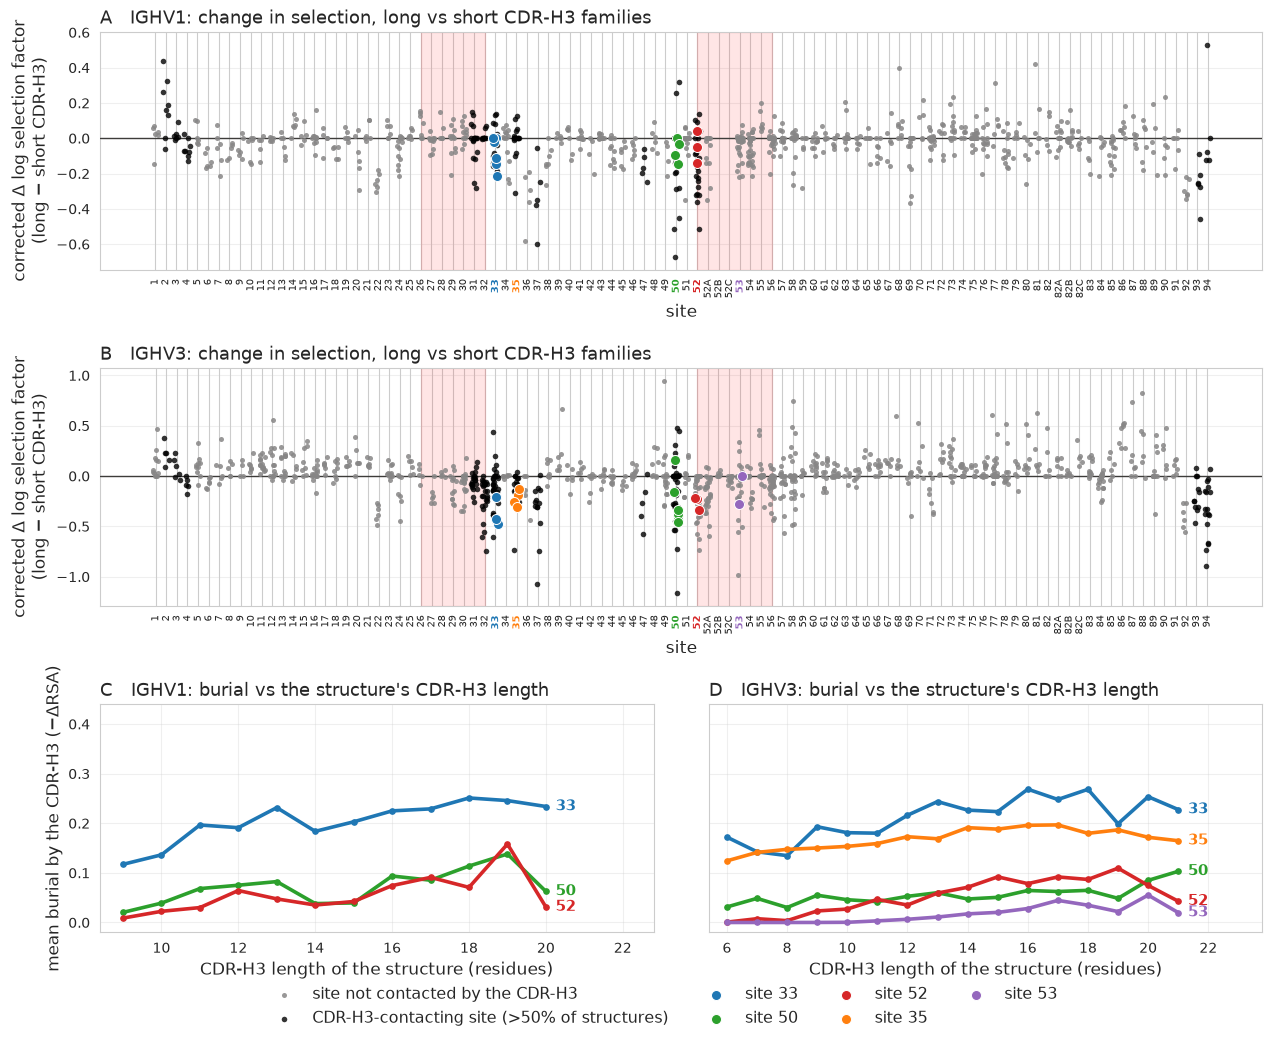

wrote _output/cdr3_dependence_of_selection/chothia/supp_cdr3_dependence.pdf
  IGHV1: 940 substitutions, 15 entrenched; median corrected shift -0.002 at contacting sites vs +0.000 elsewhere
  IGHV3: 1100 substitutions, 18 entrenched; median corrected shift -0.144 at contacting sites vs +0.000 elsewhere


In [16]:
# Summary figure: the selection shift and the structural burial on one site axis. A and B: every substitution's corrected shift between long- and
# short-CDR-H3 families, per V family. C and D: how far the CDR-H3 buries each entrenched
# site in structures of a given CDR-H3 length -- descriptive, and the reason the shifts in
# A and B point down rather than up.
FIG_ORDER = ["IGHV1", "IGHV3"]
MIN_STRUCT = 20           # structures required at a CDR-H3 length to plot that length
DARK, LIGHT = "#000000", "#878686"

# structures with a CDR-H3 length, from Section 5
_sv = sv.assign(vf=sv.v_gene_heavy.str.extract(r"(IGHV\d+)")[0],
                burial=sv.burial_by_vdj_junction)
ENT_BY = {vf: ent_sites_for(vf) for vf in FIG_ORDER}

# Same width, shorter overall: A and B lose the most height, C and D shrink as a block.
# Font sizes are in points and so are unchanged by this.
fig = plt.figure(figsize=(15, 11.4))
_gs = fig.add_gridspec(3, 2, height_ratios=[2.5, 2.5, 2.4], hspace=0.42, wspace=0.10)
axA, axB = fig.add_subplot(_gs[0, :]), fig.add_subplot(_gs[1, :])
axC, axD = fig.add_subplot(_gs[2, 0]), fig.add_subplot(_gs[2, 1])
_handles, _labels = [], []

for ax, vf, tag in [(axA, FIG_ORDER[0], "A"), (axB, FIG_ORDER[1], "B")]:
    d = split_by_family[vf]
    d = d[(d.descriptor == "cdr3_length") & d.site.isin(SITES)].copy()
    d["is_contacting"] = d.contact_class == "contacting"
    add_cdr_shading(ax, SITES, numbering_scheme=NUMBERING)
    ax.axhline(0, color="#3d3c3a", lw=1.0, zorder=3)
    rng = np.random.default_rng(1)
    _idx = {v: i for i, v in enumerate(SITES)}
    x = d.site.map(_idx).to_numpy() + (rng.random(len(d)) - 0.5) * 0.55
    plain = ~d.entrenched
    ml, md = (plain & ~d.is_contacting).to_numpy(), (plain & d.is_contacting).to_numpy()
    h1 = ax.scatter(x[ml], d.delta_corrected[ml], s=13, c=LIGHT, alpha=0.85, lw=0,
                    zorder=4, label="site not contacted by the CDR-H3")
    h2 = ax.scatter(x[md], d.delta_corrected[md], s=16, c=DARK, alpha=0.8, lw=0, zorder=5,
                    label=f"CDR-H3-contacting site "
                          f"(>{cu.CDR3_CONTACT_THRESHOLD:.0%} of structures)")
    for site in ENT_BY[vf]:
        m = (d.entrenched & (d.site == site)).to_numpy()
        h = ax.scatter(x[m], d.delta_corrected[m], s=52,
                       color=ENTRENCHED_SITE_COLORS.get(site, BLUE), edgecolor="white",
                       lw=0.7, zorder=7, label=f"site {site}")
        if f"site {site}" not in _labels:
            _handles.append(h); _labels.append(f"site {site}")
    if tag == "A":
        _handles = [h1, h2] + _handles
        _labels = [h1.get_label(), h2.get_label()] + _labels
    _lo, _hi = float(d.delta_corrected.min()), float(d.delta_corrected.max())
    ax.set_ylim(_lo - 0.06 * (_hi - _lo), _hi + 0.06 * (_hi - _lo))
    ax.set_ylabel("corrected $\\Delta$ log selection factor\n(long $-$ short CDR-H3)",
                  fontsize=12)
    ax.set_title(f"{tag}   {vf}: change in selection, long vs short CDR-H3 families",
                 loc="left", fontsize=13, pad=6)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(range(len(SITES)))
    ax.set_xticklabels(SITES, rotation=90, fontsize=7.5)
    for lbl in ax.get_xticklabels():
        if lbl.get_text() in ENT_SITES:
            lbl.set_color(ENTRENCHED_SITE_COLORS.get(lbl.get_text(), BLUE))
            lbl.set_fontweight("bold")
    ax.set_xlabel("site", fontsize=12)

for ax, vf, tag in [(axC, FIG_ORDER[0], "C"), (axD, FIG_ORDER[1], "D")]:
    d = _sv[_sv.vf == vf]
    # CDR-H3 length is an integer, so group on the exact value; lengths carried by
    # fewer than MIN_STRUCT structures are too noisy to plot
    _n_per_len = d.drop_duplicates("pdb_id").groupby("cdr3_len").size()
    d = d[d.cdr3_len.isin(_n_per_len[_n_per_len >= MIN_STRUCT].index)]
    print(f"  {vf} panel: {d.pdb_id.nunique():,} structures over CDR-H3 lengths "
          f"{int(d.cdr3_len.min())}-{int(d.cdr3_len.max())} "
          f"(of {_sv[_sv.vf == vf].pdb_id.nunique():,} before the >= {MIN_STRUCT} "
          f"per-length cut)")
    ends = []
    for site in ENT_BY[vf]:
        agg = (d[d.site == site].groupby("cdr3_len").burial.mean().rename("y")
               .reset_index().rename(columns={"cdr3_len": "x"}).sort_values("x"))
        if agg.empty:
            continue
        colr = ENTRENCHED_SITE_COLORS.get(site, BLUE)
        ax.plot(agg.x, agg.y, "-", marker="o", ms=3.8, lw=2.6, color=colr, zorder=6)
        ends.append((agg.y.iloc[-1], agg.x.iloc[-1], site, colr))
    xmax = max(e[1] for e in ends)
    ends.sort(key=lambda e: -e[0])
    _prev, _slot = None, 1
    for y, _, site, colr in ends:
        _slot = 1 - _slot if (_prev is not None and abs(_prev - y) < 0.020) else 0
        ax.annotate(site, (xmax, y), xytext=(7 + 16 * _slot, 0),
                    textcoords="offset points", fontsize=10.5, color=colr,
                    fontweight="bold", va="center")
        _prev = y
    ax.set_xlim(float(d.cdr3_len.min()) - 0.6, xmax + 2.8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_ylim(-0.02, 0.44)
    ax.set_xlabel("CDR-H3 length of the structure (residues)", fontsize=12)
    ax.set_title(f"{tag}   {vf}: burial vs the structure's CDR-H3 length", loc="left",
                 fontsize=13, pad=6)
    ax.grid(True, alpha=0.3)
axC.set_ylabel("mean burial by the CDR-H3 ($-\\Delta$RSA)", fontsize=12)
axD.tick_params(labelleft=False)

fig.legend(_handles, _labels, fontsize=11.5, loc="upper center",
           bbox_to_anchor=(0.5, 0.055), ncol=4, frameon=False)
fig.subplots_adjust(bottom=0.09)
fig.savefig(f"{OUTPUT_DIR}/supp_cdr3_dependence.pdf", dpi=300, bbox_inches="tight")
plt.show()
print(f"wrote {OUTPUT_DIR}/supp_cdr3_dependence.pdf")
for vf in FIG_ORDER:
    d = split_by_family[vf]
    d = d[d.descriptor == "cdr3_length"]
    c, n = d[d.contact_class == "contacting"], d[d.contact_class == "rest"]
    print(f"  {vf}: {len(d)} substitutions, {int(d.entrenched.sum())} entrenched; "
          f"median corrected shift {c.delta_corrected.median():+.3f} at contacting sites "
          f"vs {n.delta_corrected.median():+.3f} elsewhere")

### Caveats

- DASM applies no normalisation across amino acids or sites, so nothing here is
  architecturally forced. A mutation-model artifact is not excluded: CDR-H3 length changes
  a sequence's k-mer composition.
- Sites 93-94 are next to the CDR-H3 in sequence, so their signal may reflect proximity
  rather than structure. Sites 33, 35, 50 and 52 are close to it only in 3D.
- Sites 2 and 3 are frequently contacted but shift upward (site 4 shifts down); the
  reason is unknown.
- Site 53 is the odd entrenched site: exposed, and contacted by the CDR-H3 in only 25% of
  structures.
- Charge and hydrophobicity depend on the window. With the annotated CDR3 span, which also
  covers the V-encoded sites 93-94, hydrophobicity looked directional and charge did not.
  Over 95-102 it is the other way round, so neither result is robust.
- The floor is estimated from the same data it is subtracted from, so the corrected
  magnitudes are conservative.